# Лекция 4. Безусловная оптимизация: условия оптимальности, градиентный спуск и скорость сходимости

**Курс:** Вычислительная оптимизация · **Часть II. Безусловная оптимизация и ньютоновские методы** · Лекция 4 из 16 · 30 сентября 2026

**Материалы:** [конспект-ноутбук с кодом демонстраций](lecture04.ipynb) · [демо-ноутбук](demo04.ipynb) · [разбор упражнений](exercises04.ipynb) · [сценарий доски](board04.md)

В конспекте-ноутбуке ячейки демонстраций стоят прямо в тех разделах, к которым относятся (заголовки «Демо (0)»–«Демо (e)»): три задачи — после 1.2, стационарные точки — после раздела 3, спуск на квадратичной и регрессия — после раздела 5, Розенброк и цепь — после раздела 7. Тот же код отдельно и целиком — `demo04.ipynb`.

---

Часть I закончилась на том, как *выглядит* решение: $\nabla f=0$ для выпуклых задач без ограничений, баланс сил $\nabla f=\sum\mu_i\nabla h_i$ у стенок. Часть II — о том, как решение *находить*. Сегодня ограничений нет вовсе, $\Omega=\mathbb{R}^n$, и три вопроса:

1. Как узнать точку минимума, если функция не выпукла — что даёт $\nabla f=0$ и что добавляет гессиан?
2. Как к минимуму *идти* — куда шагать и на сколько?
3. Почему одна и та же идея — идти против градиента — на одной задаче укладывается в 18 шагов, а на другой требует 13 тысяч, и что с этим делать?

Ответ на третий вопрос — одно число, **число обусловленности** $\kappa$. Оно будет главным героем лекции.

> **Код в этом ноутбуке.** Демонстрации из [`demo04.ipynb`](demo04.ipynb) вставлены в те разделы конспекта, к которым относятся; каждая начинается с заголовка «Демо (…)». При чтении их можно пропускать, на лекции — запускать по ходу. Ячейка ниже задаёт палитру и две функции, `gd` и `newton`, которыми пользуются все демонстрации.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA, RED, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#8a8985", "#0b0b0b"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2, "legend.frameon": False})


def gd(f, grad, x0, alpha=None, tol=1e-6, maxit=100_000, c=1e-4):
    """Градиентный спуск. alpha=None — backtracking: начинаем с 1, делим пополам, пока не
    выполнено условие Армихо с константой c. Иначе — постоянный шаг alpha.
    Возвращает (x, число итераций, путь как массив (k+1, n))."""
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    for k in range(maxit):
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path)
        if alpha is None:
            a, fx = 1.0, f(x)
            while f(x - a * g) > fx - c * a * (g @ g):
                a /= 2
        else:
            a = alpha
        x = x - a * g; path.append(x.copy())
    return x, maxit, np.array(path)


def newton(grad, hess, x0, tol=1e-10, maxit=50):
    """Чистый метод Ньютона без линейного поиска. Возвращает (x, число итераций, путь)."""
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    for k in range(maxit):
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path)
        x = x - np.linalg.solve(hess(x), g); path.append(x.copy())
    return x, maxit, np.array(path)

## 1. Повторение и мост: от «как выглядит решение» к «как его найти»

### 1.1. Что уже умеем

| Вопрос | Ответ | Где |
|---|---|---|
| Есть ли минимум? | Да, если $f$ непрерывна и растёт на бесконечности ($f\to\infty$ при $\lVert x\rVert\to\infty$): множество $\{f\le f(x_0)\}$ ограничено, минимум ищется на компакте | Л1, §5 |
| Как проверить точку в выпуклой задаче? | $\nabla f(x^\ast)=0$ — необходимо и достаточно, и минимум глобальный. Для невыпуклых — «лишь необходимое условие, об этом лекция 4» | Л2, §7 |
| Что такое «решить численно»? | Итерации $x_{k+1}=x_k+p_k$, остановка при $\lVert\nabla f(x_k)\rVert\le\varepsilon$; важны число итераций и цена одной | Л1, §8 |

### 1.2. Три задачи на сегодня

<img src="img/00_hooks.png" width="900" alt="три безусловные задачи: функция Розенброка, цепь без пола, логистическая регрессия">

**Розенброк.** $f(x)=(1-x_1)^2+100\,(x_2-x_1^2)^2$ — «банановая долина». Стационарная точка находится в две строки: из $\partial f/\partial x_2=200(x_2-x_1^2)=0$ следует $x_2=x_1^2$, тогда $\partial f/\partial x_1=-2(1-x_1)=0$ даёт $x_1=1$. Точка одна — $(1,1)$, $f(1,1)=0\le f$, так что это глобальный минимум невыпуклой функции (в ДЗ 2, задача 2а, вы разберёте её гессиан подробно). Осталось до неё дойти. Это стандартный полигон для методов части II: изогнутая узкая долина, на дне которой методы ползут.

**Цепь без пола** (лекция 1, §7.3). $40$ грузов на пружинах, $80$ переменных, минимум энергии — выпуклая квадратичная задача. Без ограничений её решает `np.linalg.solve`, но сегодня мы запустим на ней градиентный спуск и увидим, что даже выпуклая квадратичная задача может быть *трудной*.

**Логистическая регрессия** (лекция 1, §7.5). По возрасту и стажу предсказать класс: найти $w$, минимизирующий $\frac1n\sum_i\log(1+e^{-y_i x_i^\top w})$. Выпуклая, гладкая, без ограничений — и на ней градиентный спуск без одной простой подготовки не сходится вовсе.

Во всех трёх задачах нет ни одной стенки. Вспомним систему условий оптимальности лекции 3: $\nabla_xL=0$, допустимость, $\mu\ge0$, $\mu_ih_i=0$. Нет ограничений — нет множителей, и вся система сводится к одному уравнению $\nabla f(x^\ast)=0$. **Нет стенок — нет сил.**

**Что мы знаем о множителях и чего пока нет.** После лекции 3 у множителя два прочтения — сила реакции стенки и цена ограничения, — а система ККТ — сертификат: подставили решение и множители, все нули — решение доказано. Чего мы *не* умеем: находить множители, не угадывая заранее, какие стенки активны, и получать гарантированные оценки $f^\ast$ снизу. Это даёт **двойственность Лагранжа** — лекция 10; кому не терпится, черновик лежит в [`lectures/extra/duality.md`](../extra/duality.md). Задача 4 в ДЗ 2 продолжает тему множителей уже сейчас.

### Демо (0). Три задачи-крючка

Раздел 1 конспекта. Три задачи из прошлых лекций, у которых **нет ограничений**: ни равенств, ни неравенств, ни ящика — минимизируем по всему $\mathbb R^n$. В лекциях 1–3 мы решали их солвером «как чёрным ящиком»; сегодня разбираем, что внутри. Здесь только определяем функции, градиенты и гессианы и смотрим на данные — считать будем в частях (a)–(e).

**Задача А. Функция Розенброка** $f(x)=(1-x_1)^2+100\,(x_2-x_1^2)^2$. Минимум $f=0$ в $(1,1)$, лежит на дне узкой изогнутой долины $x_2=x_1^2$. Линии уровня — в логарифмическом масштабе, иначе долину не видно.

f(1,1) = 0.0   grad f(1,1) = [-0.  0.]
старт (-1.2, 1): f = 24.2  |grad f| = 232.87


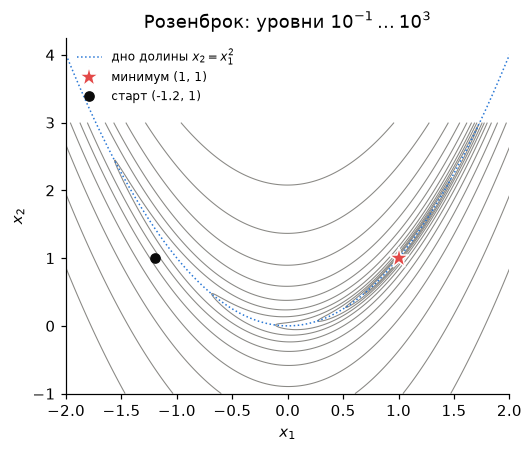

In [2]:
rosen = lambda x: (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2
rosen_grad = lambda x: np.array([-2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0]**2), 200 * (x[1] - x[0]**2)])
rosen_hess = lambda x: np.array([[2 - 400 * x[1] + 1200 * x[0]**2, -400 * x[0]], [-400 * x[0], 200]])

x_star = np.array([1.0, 1.0])
print("f(1,1) =", rosen(x_star), "  grad f(1,1) =", rosen_grad(x_star))
print("старт (-1.2, 1): f =", round(rosen(np.array([-1.2, 1.0])), 3), " |grad f| =", np.linalg.norm(rosen_grad(np.array([-1.2, 1.0]))).round(2))

xs, ys = np.linspace(-2, 2, 400), np.linspace(-1, 3, 400)
X1, X2 = np.meshgrid(xs, ys)
F_rosen = (1 - X1)**2 + 100 * (X2 - X1**2)**2

fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.contour(X1, X2, F_rosen, levels=np.logspace(-1, 3, 12), colors=[GRAY], linewidths=0.7)
ax.plot(xs, xs**2, ls=":", color=BLUE, lw=1, label="дно долины $x_2=x_1^2$")
ax.plot(1, 1, "*", ms=14, color=RED, mec="white", label="минимум (1, 1)")
ax.plot(-1.2, 1, "o", color=INK, label="старт (-1.2, 1)")
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="Розенброк: уровни $10^{-1}\dots10^{3}$"); ax.legend(loc="upper left", fontsize=8); ax.grid(False)
plt.show()

**Задача Б. Цепь без пола** (лекция 1, §7.3). $N$ грузов массой $m=4/N$ на пружинах жёсткости $D=70$ между креплениями $(-2,1)$ и $(2,1)$; переменные $v=(y_1..y_N,\,z_1..z_N)$, энергия $E(v)=\tfrac D2\sum_i\big((y_{i+1}-y_i)^2+(z_{i+1}-z_i)^2\big)+mg\sum_i z_i$. Энергия **квадратичная**: градиент линеен по $v$, гессиан постоянен — $\nabla^2E=\operatorname{diag}(DK,\,DK)$ с трёхдиагональной $K$ ($2$ на диагонали, $-1$ рядом). Значит минимум — решение линейной системы $\nabla^2E\,v=-\nabla E(0)$. Проверяем, что собранная матрица действительно гессиан: $\nabla E(v)-\nabla E(0)=Hv$ для случайного $v$.

проверка гессиана: max |grad E(v) - grad E(0) - H v| = 0.0
энергия на старте (прямая): 52.8985,  в минимуме: 13.4417,  |grad E| в минимуме: 9.0e-14


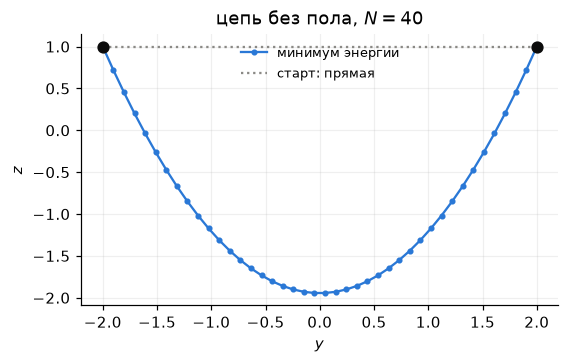

In [3]:
D_CHAIN, G_CHAIN = 70.0, 9.81
p_left, p_right = np.array([-2.0, 1.0]), np.array([2.0, 1.0])


def make_chain(N):
    """Энергия, градиент, гессиан и стартовая точка (прямая между концами) для цепи из N грузов."""
    m = 4.0 / N

    def unpack(v):
        return np.r_[p_left[0], v[:N], p_right[0]], np.r_[p_left[1], v[N:], p_right[1]]

    def energy(v):
        y, z = unpack(v)
        return 0.5 * D_CHAIN * np.sum(np.diff(y)**2 + np.diff(z)**2) + m * G_CHAIN * np.sum(z[1:-1])

    def grad_E(v):
        y, z = unpack(v)
        return np.r_[D_CHAIN * (2 * y[1:-1] - y[:-2] - y[2:]), D_CHAIN * (2 * z[1:-1] - z[:-2] - z[2:]) + m * G_CHAIN]

    K = 2 * np.eye(N) - np.eye(N, k=1) - np.eye(N, k=-1)
    H = np.kron(np.eye(2), D_CHAIN * K)
    v0 = np.r_[np.linspace(p_left[0], p_right[0], N + 2)[1:-1], np.linspace(p_left[1], p_right[1], N + 2)[1:-1]]
    return energy, grad_E, unpack, K, H, v0


N = 40
energy, grad_E, unpack, K, H, v0 = make_chain(N)
v_test = np.random.default_rng(0).normal(size=2 * N)     # случайный вектор для проверки; генератор локальный, ячейка перезапускается сама по себе
print("проверка гессиана: max |grad E(v) - grad E(0) - H v| =", np.abs(grad_E(v_test) - grad_E(np.zeros(2 * N)) - H @ v_test).max().round(12))

v_chain = np.linalg.solve(H, -grad_E(np.zeros(2 * N)))
print(f"энергия на старте (прямая): {energy(v0):.4f},  в минимуме: {energy(v_chain):.4f},  |grad E| в минимуме: {np.linalg.norm(grad_E(v_chain)):.1e}")

y, z = unpack(v_chain)
plt.figure(figsize=(5.6, 3.2))
plt.plot(y, z, "-o", ms=3, color=BLUE, label="минимум энергии")
plt.plot(*unpack(v0), ls=":", color=GRAY, label="старт: прямая")
plt.plot([-2, 2], [1, 1], "o", color=INK, ms=7)
plt.xlabel("$y$"); plt.ylabel("$z$"); plt.legend(loc="upper center", fontsize=8.5); plt.title(f"цепь без пола, $N={N}$")
plt.show()

**Задача В. Логистическая регрессия** (лекция 1, §7.5). Синтетические данные: $n=200$ человек, признаки — возраст (лет) и стаж (лет), класс $y\in\{0,1\}$ разыгрывается с вероятностью $\sigma(1.5z_1-z_2+0.3)$ по стандартизованным $z$. Модель: $\Pr(y=1\mid x)=\sigma(w^\top x)$, $x=(1,\text{возраст},\text{стаж})$; цель $f(w)=\frac1n\sum_i\log\big(1+e^{-\tilde y_i\,x_i^\top w}\big)$, $\tilde y_i=2y_i-1\in\{-1,1\}$ — гладкая, выпуклая, без ограничений. Обратите внимание на масштабы признаков: возраст разбросан на $\pm10$, стаж — на $\pm1$. Это выстрелит в части (d).

объектов: 200, класс 1: 119, класс 0: 81
возраст: среднее 40.5, std 10.0;   стаж: среднее 5.02, std 1.02


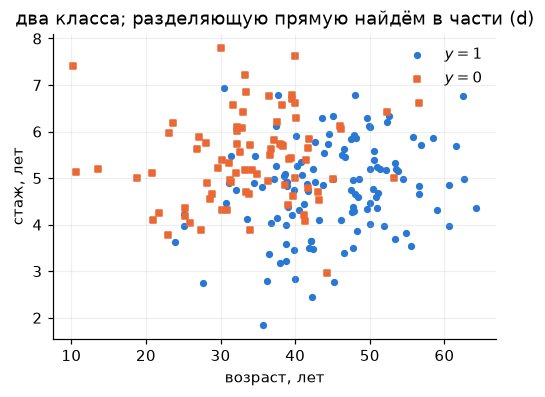

In [4]:
rng = np.random.default_rng(4)          # заново, чтобы ячейку можно было перезапускать: данные должны быть теми же
n = 200
z1, z2 = rng.normal(0, 1, n), rng.normal(0, 1, n)
p_true = 1 / (1 + np.exp(-(1.5 * z1 - 1.0 * z2 + 0.3)))
y_cls = (rng.uniform(size=n) < p_true).astype(float)
age, exper = 40 + 10 * z1, 5 + z2
X = np.c_[np.ones(n), age, exper]

print(f"объектов: {n}, класс 1: {int(y_cls.sum())}, класс 0: {int(n - y_cls.sum())}")
print(f"возраст: среднее {age.mean():.1f}, std {age.std():.1f};   стаж: среднее {exper.mean():.2f}, std {exper.std():.2f}")

plt.figure(figsize=(5.2, 3.6))
plt.scatter(age[y_cls == 1], exper[y_cls == 1], s=14, color=BLUE, label="$y=1$")
plt.scatter(age[y_cls == 0], exper[y_cls == 0], s=14, color=ORANGE, marker="s", label="$y=0$")
plt.xlabel("возраст, лет"); plt.ylabel("стаж, лет"); plt.legend(); plt.title("два класса; разделяющую прямую найдём в части (d)")
plt.show()

Итак: три задачи, ни одного ограничения, все три — **безусловные** ($\min_{x\in\mathbb R^n}f(x)$). Розенброк — гладкая, невыпуклая, с одной стационарной точкой; цепь — квадратичная и выпуклая; логистическая регрессия — выпуклая, но не квадратичная. Все три решаем сегодня, и на всех трёх увидим одно и то же: скорость градиентного спуска диктует число обусловленности гессиана.

### 1.3. Что сегодня

Условия оптимальности первого и второго порядка (разделы 2–3) → градиентный спуск: направление, шаг, лемма о спуске (4) → число обусловленности и скорость (5–6) → один шаг Ньютона как тизер лекции 5 (7). Семинар — задачи у доски (11–12).

## 2. Стационарные точки: условие первого порядка

**Теорема (необходимое условие первого порядка).** Если $x^\ast$ — локальный минимум $f\in C^1$ на $\mathbb{R}^n$, то $\nabla f(x^\ast)=0$.

*Доказательство.* Пусть $g=\nabla f(x^\ast)\ne0$. Пойдём против градиента: по Тейлору $f(x^\ast-tg)=f(x^\ast)-t\lVert g\rVert^2+o(t)$, и при малом $t>0$ значение меньше $f(x^\ast)$ — сколь угодно близко к $x^\ast$ есть точки лучше. Противоречие с локальностью минимума. $\square$

Точки с $\nabla f=0$ называются **стационарными**. Теорема говорит только «минимум — стационарная точка», но не наоборот: стационарной может быть и точка максимума, и **седло** — точка, из которой в одни стороны функция растёт, а в другие убывает.

<img src="img/01_stationary.png" width="900" alt="минимум, максимум и седло: линии уровня и поле антиградиентов">

Стрелки — антиградиент $-\nabla f$, то есть направление, куда пойдёт спуск. В минимуме стрелки сходятся, в максимуме расходятся, в седле — сходятся вдоль одной оси и расходятся вдоль другой. Для методов часть II это важнее, чем кажется: градиентный спуск ищет точку, где стрелки исчезают, и седло для него — такая же стационарная точка, как минимум (упражнение 12.1). Спасает только то, что седло **неустойчиво**: любое отклонение с «хребта» уводит вниз.

**Обозначения на всю часть II.** $x^\ast$ — минимум, $e_k=x_k-x^\ast$ — ошибка $k$-й итерации, $g_k=\nabla f(x_k)$, $H(x)=\nabla^2f(x)$ — гессиан, симметричная матрица $n\times n$.

## 3. Второй порядок: необходимое, достаточное и зазор между ними

Раз первого порядка мало, привлекаем гессиан. По Тейлору второго порядка вдоль направления $p$:

$$
f(x^\ast+tp)=f(x^\ast)+t\,\nabla f(x^\ast)^\top p+\tfrac12t^2\,p^\top\nabla^2f(x^\ast)\,p+o(t^2).
$$

В стационарной точке средний член нуль, и всё решает знак квадратичной формы.

**Теорема (второй порядок).** Пусть $f\in C^2$.

- *Необходимое условие:* если $x^\ast$ — локальный минимум, то $\nabla f(x^\ast)=0$ и $\nabla^2f(x^\ast)\succeq0$.
- *Достаточное условие:* если $\nabla f(x^\ast)=0$ и $\nabla^2f(x^\ast)\succ0$, то $x^\ast$ — **строгий** локальный минимум.

*Доказательство.* Необходимость: будь $p^\top Hp<0$ для какого-то $p$, вдоль $p$ функция убывала бы при малых $t$ — снова точки лучше рядом. Достаточность: $p^\top Hp\ge\lambda_{\min}\lVert p\rVert^2>0$, а остаток $o(t^2)$ мал равномерно по единичным $p$ (гессиан непрерывен), поэтому при малых $t$ квадратичный член перевешивает и $f(x^\ast+tp)>f(x^\ast)$ для всех $p\ne0$. $\square$

**Зазор.** Между $\succeq0$ и $\succ0$ есть щель, и в ней условия молчат. Три функции одной переменной — $x^4$, $x^3$, $-x^4$ — имеют в нуле одинаковые $f'(0)=f''(0)=0$, а судьбы разные: минимум, не экстремум, максимум. Различить их могут только старшие производные, и общего рецепта нет; в двух переменных то же: $x_1^2+x_2^4$ и $x_1^2-x_2^4$ имеют один гессиан $\operatorname{diag}(2,0)$ (упражнение 12.2).

<img src="img/02_second_order.png" width="900" alt="зазор между условиями: x^4, x^3, -x^4; четыре квадратичных ландшафта">

**Квадратичный случай — без зазора.** Для $f(x)=\tfrac12x^\top Qx+c^\top x$ гессиан постоянен и равен $Q$, остатка Тейлора нет, и ответ полный:

| $Q$ | Ландшафт | Стационарные точки |
|---|---|---|
| $Q\succ0$ | чаша | одна, $x^\ast=-Q^{-1}c$ — глобальный минимум (лекция 2, §7) |
| $Q$ индефинитна, невырождена | седло | одна, $-Q^{-1}c$, но это не минимум: вдоль собственного вектора с $\lambda<0$ функция уходит в $-\infty$ (если $Q$ ещё и вырождена, стационарных точек либо целая прямая, либо нет вовсе — $f\to-\infty$ в любом случае) |
| $Q\succeq0$ вырождена, $c\in\operatorname{range}Q$ | жёлоб | целая прямая (плоскость) минимумов — как в МНК с линейно зависимыми столбцами |
| $Q\succeq0$ вырождена, $c\notin\operatorname{range}Q$ | наклонный жёлоб | стационарных точек нет, $f\to-\infty$ вдоль жёлоба |

Эта таблица понадобится в лекции 5: метод Ньютона на каждом шаге минимизирует именно такую модель, и «седло» в таблице означает, что шаг Ньютона может пойти *вверх*.

**Выпуклость закрывает зазор.** Если $f$ выпукла, $\nabla f(x^\ast)=0$ — необходимо и достаточно, и минимум глобальный (лекция 2, §7): гессиан здесь не нужен вообще. Гессиан нужен ровно тогда, когда выпуклости нет.

**Розенброк.** Из ДЗ 2: единственная стационарная точка $(1,1)$, в ней

$$
\nabla^2f(1,1)=\begin{pmatrix}802&-400\\-400&200\end{pmatrix},\qquad \lambda_{\min}\approx0.40,\quad\lambda_{\max}\approx1001.6 .
$$

Оба собственных числа положительны (что это за числа и почему они здесь главные — §5.1) — по достаточному условию это строгий локальный минимум, а так как $f\ge0=f(1,1)$, ещё и глобальный. Запомните эти два числа: их отношение $\kappa\approx2508$ объяснит всё, что случится с градиентным спуском в разделе 5.

### Демо (a). Стационарные точки и гессиан

Разделы 2–3 конспекта, упражнение 12.1. Пример из лекции 2: $f(x)=(x_1^2-1)^2+x_2^2$, $\nabla f=(4x_1(x_1^2-1),\,2x_2)$. Условие первого порядка $\nabla f=0$ даёт три точки: $(0,0)$ и $(\pm1,0)$. Гессиан $\nabla^2f=\operatorname{diag}(12x_1^2-4,\,2)$ — смотрим на его собственные числа: все положительны — строгий минимум, есть отрицательное — седло (не минимум). На картинке — поле $-\nabla f$ (куда пойдёт градиентный спуск): к минимумам стрелки сходятся, от седла вдоль $x_1$ — расходятся.

точка [0. 0.]: |grad f| = 0e+00,  собственные числа гессиана [-4.  2.]  ->  седло, f = 1
точка [1. 0.]: |grad f| = 0e+00,  собственные числа гессиана [2. 8.]  ->  строгий минимум, f = 0
точка [-1.  0.]: |grad f| = 0e+00,  собственные числа гессиана [2. 8.]  ->  строгий минимум, f = 0
GD из [0.0, 0.5]: пришёл в [0. 0.] за 1 итераций
GD из [0.01, 0.5]: пришёл в [1. 0.] за 16 итераций


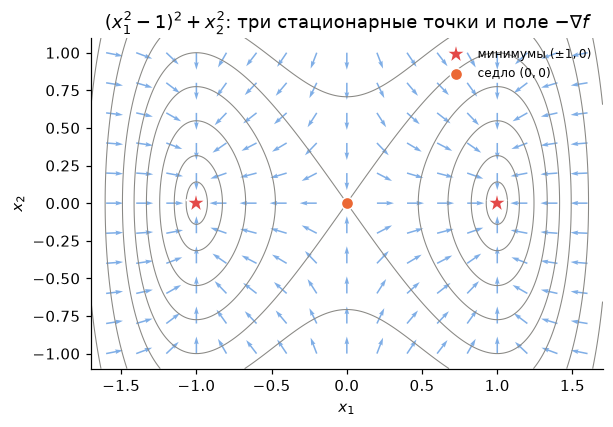

In [5]:
f_a = lambda x: (x[0]**2 - 1)**2 + x[1]**2
grad_a = lambda x: np.array([4 * x[0] * (x[0]**2 - 1), 2 * x[1]])
hess_a = lambda x: np.diag([12 * x[0]**2 - 4, 2.0])

for pt in ([0.0, 0.0], [1.0, 0.0], [-1.0, 0.0]):
    pt = np.array(pt); lam = np.linalg.eigvalsh(hess_a(pt))
    kind = "строгий минимум" if lam.min() > 0 else ("седло" if lam.min() < 0 < lam.max() else "максимум")
    print(f"точка {pt}: |grad f| = {np.linalg.norm(grad_a(pt)):.0e},  собственные числа гессиана {lam}  ->  {kind}, f = {f_a(pt):.0f}")

# упражнение 12.1: куда придёт градиентный спуск из (0, 0.5) и из (0.01, 0.5)?
for x0 in ([0.0, 0.5], [0.01, 0.5]):
    x, k, _ = gd(f_a, grad_a, x0)
    print(f"GD из {x0}: пришёл в {x.round(6)} за {k} итераций")

xs = np.linspace(-1.7, 1.7, 300); ys = np.linspace(-1.1, 1.1, 300)
X1, X2 = np.meshgrid(xs, ys)
Fa = (X1**2 - 1)**2 + X2**2
qx, qy = np.meshgrid(np.arange(-1.6, 1.61, 0.2), np.arange(-1.0, 1.01, 0.2))
U, V = -4 * qx * (qx**2 - 1), -2 * qy
nrm = np.hypot(U, V) + 1e-12
fig, ax = plt.subplots(figsize=(6, 4))
ax.contour(X1, X2, Fa, levels=[0.02, 0.1, 0.3, 0.6, 1, 1.5, 2.5, 4], colors=[GRAY], linewidths=0.7)
ax.quiver(qx, qy, U / nrm, V / nrm, color=BLUE, alpha=0.6, scale=30, width=0.003)
ax.plot([1, -1], [0, 0], "*", ms=14, color=RED, mec="white", ls="none", label="минимумы $(\pm1,0)$")
ax.plot(0, 0, "o", ms=8, color=ORANGE, mec="white", label="седло $(0,0)$")
ax.set(aspect="equal", xlabel="$x_1$", ylabel="$x_2$", title="$(x_1^2-1)^2+x_2^2$: три стационарные точки и поле $-\\nabla f$"); ax.legend(loc="upper right", fontsize=8); ax.grid(False)
plt.show()

Из $(0,0.5)$ спуск пришёл в **седло**: первая компонента градиента там тождественно нуль, $x_1$ так и остаётся нулём, и метод честно нашёл стационарную точку, а не минимум. Сдвиг старта на $0.01$ всё меняет: $x_1$ растёт, и приходим в $(1,0)$. Мораль раздела 2: градиентный спуск гарантирует только $\nabla f=0$; к седлу он сходится лишь со множества меры нуль.

**Розенброк.** Гессиан в $(1,1)$ равен $\begin{pmatrix}802&-400\\-400&200\end{pmatrix}$; должны увидеть собственные числа $0.3994$ и $1001.6$ — оба положительны (минимум), но отличаются в $\kappa\approx2508$ раз. Единственность стационарной точки — аналитически: из второго уравнения $200(x_2-x_1^2)=0$ следует $x_2=x_1^2$, тогда первое даёт $-2(1-x_1)=0$, то есть $x_1=1$. Численно — метод Ньютона для системы $\nabla f=0$ (функция `newton` из первой ячейки) из 20 случайных стартов в $[-2,2]\times[-1,3]$: все 20 должны прийти в $(1,1)$, за 5–7 итераций каждый. (Библиотечный солвер `scipy.optimize.root` из части этих же стартов «застревает» — это артефакт настроек его доверительной области, а не свойство задачи и не свойство метода Ньютона.)

In [6]:
H1 = rosen_hess(np.array([1.0, 1.0]))
lam = np.linalg.eigvalsh(H1)
print("гессиан в (1,1):\n", H1)
print(f"собственные числа: {lam[0]:.4f} и {lam[1]:.1f};  κ = {lam[1] / lam[0]:.1f}")

rng = np.random.default_rng(11)                       # локальный генератор: ячейка перезапускается независимо
starts = np.c_[rng.uniform(-2, 2, 20), rng.uniform(-1, 3, 20)]
runs = [newton(rosen_grad, rosen_hess, s) for s in starts]
ends, its = np.array([r[0] for r in runs]), np.array([r[1] for r in runs])
hit = np.linalg.norm(ends - 1, axis=1) < 1e-8
print(f"Ньютон из {len(starts)} стартов: в (1,1) пришли {hit.sum()} из {len(starts)}"
      + (f", итераций {its[hit].min()}..{its[hit].max()}" if hit.any() else ""))
print("уникальные найденные стационарные точки:", np.unique(ends[hit].round(6), axis=0) if hit.any() else "нет")
if not hit.all():
    print("не пришли в (1,1) (старт -> конец, |grad f|):", [(s.round(2), e.round(3), f"{np.linalg.norm(rosen_grad(e)):.1e}") for s, e in zip(starts[~hit], ends[~hit])])

гессиан в (1,1):
 [[ 802. -400.]
 [-400.  200.]]
собственные числа: 0.3994 и 1001.6;  κ = 2508.0
Ньютон из 20 стартов: в (1,1) пришли 20 из 20, итераций 5..7
уникальные найденные стационарные точки: [[1. 1.]]


$\kappa=2508$ — это «длина долины к её ширине». Часть (b) покажет, что это число — сколько итераций спуска нужно на одну верную цифру.

## 4. Градиентный спуск: направление, шаг, лемма о спуске

Условия найдены; теперь — как к ним прийти. Итерационный метод из лекции 1 (§8): $x_{k+1}=x_k+p_k$. Два вопроса: куда шагать и на сколько. Обозначим градиент в текущей точке $g=\nabla f(x)$.

### 4.1. Куда идти

Пусть $p$ — единичный вектор. Скорость изменения $f$ при движении из $x$ в направлении $p$ — производная по направлению — равна скалярному произведению $g^\top p$. Запишем его через угол $\theta$ между $g$ и $p$:

$$
g^\top p=\lVert g\rVert\cdot\lVert p\rVert\cdot\cos\theta=\lVert g\rVert\cos\theta .
$$

Косинус меняется от $-1$ до $1$, и эта формула отвечает на три вопроса сразу:

- $\theta=180^\circ$, то есть $p=-g/\lVert g\rVert$: скорость $-\lVert g\rVert$ — самое быстрое убывание. **Антиградиент — направление самого крутого спуска.**
- $\theta>90^\circ$: скорость отрицательна. Все такие $p$ — **направления спуска**; они заполняют полуплоскость (в $\mathbb{R}^n$ — полупространство) по ту сторону от градиента.
- $\theta=90^\circ$: скорость нуль — в первом порядке функция не меняется. Такие $p$ касаются линии уровня; значит, **градиент перпендикулярен линии уровня**.

<img src="img/03_descent_direction.png" width="900" alt="направления спуска на линиях уровня; функция одного шага φ(α)">

### 4.2. Метод и функция одного шага

Градиентный спуск — это

$$
\boxed{\;x_{k+1}=x_k-\alpha_k\,g_k\;}\qquad g_k=\nabla f(x_k),
$$

и вся содержательная часть — в выборе длины шага $\alpha_k$.

Чтобы думать о шаге, сведём задачу к одной переменной. Зафиксируем точку $x_k$ и направление $-g_k$; тогда значение функции зависит только от длины шага:

$$
\varphi(\alpha)=f(x_k-\alpha g_k).
$$

Это «функция одного шага» — сечение $f$ вдоль луча (правая панель картинки выше). Её производная в нуле — по цепному правилу, производная $f$ по направлению $-g_k$:

$$
\varphi'(0)=\nabla f(x_k)^\top(-g_k)=-\lVert g_k\rVert^2<0 .
$$

Значит, при достаточно малых $\alpha$ функция убывает. Слишком малый шаг — почти не сдвинулись; слишком большой — перелетели дно и стало хуже. Нужно понять, какой шаг «достаточно малый».

### 4.3. Какой шаг безопасен: лемма о спуске

**Шаг 1. Что мы знаем о функции впереди.** В точке $x_k$ известны высота и наклон. Про то, что дальше, договоримся знать одно число — $L$, границу кривизны: вторая производная по любому направлению не превосходит $L$. Одномерно: $f''(t)\le L$ всюду. Для квадратичной $\tfrac12x^\top Qx$ это наибольшее собственное число $Q$ — кривизна вдоль самого крутого направления (что такое собственные числа — §5.1). У Розенброка возле минимума $L\approx1000$.

**Шаг 2. Парабола сверху.** Если кривизна не больше $L$, функция не может загибаться вверх круче параболы кривизны $L$. Одномерно это формула Тейлора с оценкой остатка: сдвинувшись из $x$ на $p$,

$$
f(x+p)\le f(x)+f'(x)\,p+\frac L2\,p^2 .
$$

В $n$ измерениях то же самое: $f(x+p)\le f(x)+g^\top p+\frac L2\lVert p\rVert^2$. Справа — парабола, касающаяся $f$ в точке $x$; функция лежит под ней (картинка ниже; доказательство — упражнение 12.6).

<img src="img/08_descent_lemma.png" width="720" alt="лемма о спуске: функция лежит под параболой кривизны L">

**Шаг 3. Подставляем наш шаг.** Градиентный спуск сдвигается на $p=-\alpha g$. Считаем два слагаемых параболы:

$$
g^\top p=g^\top(-\alpha g)=-\alpha\lVert g\rVert^2,\qquad
\frac L2\lVert p\rVert^2=\frac L2\,\alpha^2\lVert g\rVert^2 .
$$

Складываем и выносим общий множитель $\alpha\lVert g\rVert^2$:

$$
f(x-\alpha g)\;\le\;f(x)-\alpha\lVert g\rVert^2+\frac L2\alpha^2\lVert g\rVert^2
\;=\;f(x)-\alpha\Big(1-\frac{\alpha L}{2}\Big)\lVert g\rVert^2 .
$$

**Шаг 4. Читаем формулу.** Из $f(x)$ вычитается произведение трёх множителей — гарантированное убывание за шаг:

- $\lVert g\rVert^2$ — насколько круто. В минимуме $g=0$: убывать больше нечему.
- $\alpha$ — насколько далеко шагнули.
- $1-\alpha L/2$ — **штраф за загиб**: склон не прямой, он загибается вверх, и чем дальше шаг, тем больше загиб съедает. Единственный множитель, который может обратиться в нуль или стать отрицательным.

| шаг $\alpha$ | штраф $1-\alpha L/2$ | что это значит |
|---|---|---|
| $1/(2L)$ | $3/4$ | загиб съел четверть |
| $1/L$ | $1/2$ | загиб съел половину, но убывание $\alpha(1-\alpha L/2)\lVert g\rVert^2=\lVert g\rVert^2/(2L)$ — наибольшее из гарантированных |
| $2/L$ | $0$ | загиб съел всё: гарантии нет |
| $3/L$ | $-1/2$ | парабола выше исходной точки: функция может вырасти |

Почему наибольшее убывание при $1/L$: $\alpha(1-\alpha L/2)=\alpha-\alpha^2L/2$ — парабола по $\alpha$ ветвями вниз, её вершина в $\alpha=1/L$. Это та же точка, что минимум параболы на картинке.

Числа для ощущения: $L=10$, $\lVert g\rVert=3$. Шаг $0.05$ гарантирует убывание $0.05\cdot0.75\cdot9=0.34$; шаг $0.1=1/L$ — $0.45$; шаг $0.15$ — снова $0.34$; шаг $0.2=2/L$ — ничего.

**Вывод: шаг $\alpha<2/L$ безопасен, $\alpha=1/L$ — лучший из гарантированных.** Граница настоящая: на квадратичной функции с кривизной ровно $L$ шаг больше $2/L$ перепрыгивает дно и уходит выше, а у Розенброка шаг $0.0019$ сходится, шаг $0.002$ — уже нет (раздел 5).

**Шаг 5. Почему метод сходится.** Каждая итерация с $\alpha=1/L$ снимает с $f$ не меньше $\lVert g_k\rVert^2/(2L)$. Сложим по всем итерациям: суммарное убывание не может превысить $f(x_0)-f^\ast$ — ниже минимума не упасть. Значит,

$$
\sum_k\frac{\lVert g_k\rVert^2}{2L}\le f(x_0)-f^\ast<\infty,
$$

и слагаемые стремятся к нулю: $\lVert g_k\rVert\to0$. Метод не расходится и не застревает — он спускается, пока градиент не обнулится. Если множество уровня $\{f\le f(x_0)\}$ ограничено (лекция 1, §5), итерации не убегают на бесконечность и их предельные точки стационарны; для выпуклой $f$ это глобальный минимум.

### 4.4. Точный шаг на квадратичной функции

Раз $\varphi(\alpha)$ — функция одной переменной, можно взять $\alpha$ в её минимуме. В общем случае это отдельная задача, а для квадратичной $f=\tfrac12x^\top Qx+c^\top x$ ответ выписывается. Градиент $g=Qx+c$. Подставим $x-\alpha g$ и раскроем скобки по частям:

$$
\tfrac12(x-\alpha g)^\top Q(x-\alpha g)=\tfrac12x^\top Qx-\alpha\,g^\top Qx+\tfrac12\alpha^2\,g^\top Qg,
\qquad
c^\top(x-\alpha g)=c^\top x-\alpha\,c^\top g .
$$

Складываем. Первые слагаемые дают $f(x)$; средние — $-\alpha\,(g^\top Qx+c^\top g)=-\alpha\,g^\top(Qx+c)=-\alpha\lVert g\rVert^2$. Итого

$$
\varphi(\alpha)=f(x)-\alpha\lVert g\rVert^2+\tfrac12\alpha^2\,g^\top Qg
$$

— парабола по $\alpha$ ветвями вверх. Её минимум там, где производная нуль:

$$
\varphi'(\alpha)=-\lVert g\rVert^2+\alpha\,g^\top Qg=0
\quad\Longrightarrow\quad
\boxed{\;\alpha^\ast=\frac{\lVert g\rVert^2}{g^\top Qg}\;}
$$

Что это за число: $g^\top Qg/\lVert g\rVert^2$ — кривизна функции вдоль направления $g$; она лежит между $\lambda_{\min}$ и $\lambda_{\max}$ (§5.1), поэтому $1/\lambda_{\max}\le\alpha^\ast\le1/\lambda_{\min}$. Точный шаг никогда не короче безопасного $1/L$ — и ровно равен ему, когда градиент смотрит вдоль самого крутого направления. Для неквадратичной $f$ явной формулы нет, и точный поиск заменяют приближённым.

### 4.5. Backtracking: шаг без знания $L$

На практике $L$ неизвестна. Обойдёмся без неё: пробуем большой шаг, и если функция не уменьшилась — делим шаг пополам, пока не уменьшится.

```python
alpha = 1.0
while f(x - alpha * g) >= f(x):
    alpha /= 2
x = x - alpha * g
```

Почему цикл конечен: как только $\alpha$ станет меньше $2/L$, лемма о спуске гарантирует убывание. Почему это хорошо: шаг подстраивается под кривизну там, где мы находимся — вдали от минимума, где долина шире, шаги крупнее, чем позволил бы глобальный $1/L$. В демо проверка чуть строже — требуется убывание хотя бы на $10^{-4}\,\alpha\lVert g\rVert^2$, а не просто «стало меньше»; зачем нужна эта добавка и как выбирать шаг ещё лучше — лекция 6.

### 4.6. Когда остановиться

Как в лекции 1: $\lVert g_k\rVert\le\varepsilon$. Для выпуклой $f$ малый градиент означает близость к глобальному минимуму, для невыпуклой — к стационарной точке; какой именно, метод не знает.

Насколько близко — обещание лекции 2 (§8), выполняем сейчас. Пусть кривизна всюду не меньше $m>0$ (функция сильно выпукла). В минимуме $g(x^\ast)=0$; по пути от $x^\ast$ до $x$ градиент накапливался со скоростью не меньше $m$ на единицу длины, поэтому

$$
\lVert g(x)\rVert\ge m\,\lVert x-x^\ast\rVert
\quad\Longrightarrow\quad
\lVert x-x^\ast\rVert\le\frac{\lVert g(x)\rVert}{m}.
$$

При маленьком $m$ — пологая долина — малый градиент гарантирует немногое: можно быть далеко от минимума и почти не чувствовать наклона. Это ещё одна причина, по которой в разделе 5 регрессия без масштабирования не доходит до $\varepsilon=10^{-6}$.

## 5. Скорость: число обусловленности

Метод сходится. Но *как быстро*? Ответ виден на квадратичной функции $f=\tfrac12x^\top Qx$, а к общей переносится почти дословно. Чтобы его прочитать, нужно одно понятие — собственные числа матрицы $Q$.

### 5.1. Собственные числа на пальцах

**Матрица растягивает и поворачивает стрелки.** Возьмём вектор $v$ и умножим: $Qv$. Обычно результат смотрит в другую сторону и имеет другую длину. Но у симметричной $Q$ есть особые направления, вдоль которых стрелка после умножения только растягивается, не поворачиваясь: $Qv=\lambda v$. Это **собственные векторы**, а множитель растяжения $\lambda$ — **собственное число**. У симметричной матрицы $2\times2$ таких направлений ровно два, и они перпендикулярны.

**Собственные направления — оси эллипсов.** Идём из центра вдоль собственного вектора $v$ на расстояние $t$: $f(tv)=\tfrac12t^2\,v^\top Qv=\tfrac12\lambda t^2$ — обычная парабола с кривизной $\lambda$. Значит, **собственное число — это кривизна чаши вдоль её главной оси.** Где $\lambda$ большое, функция растёт круто и эллипс линии уровня узкий; где маленькое — полого, эллипс длинный. Полуоси эллипса относятся как $1/\sqrt\lambda$.

**Между осями кривизна плавно меняется.** Если крутить единичную стрелку $v$ по кругу и смотреть на $v^\top Qv$ — кривизну в этом направлении, — получится волна: максимум $\lambda_{\max}$ на одной оси, минимум $\lambda_{\min}$ на перпендикулярной, между ними плавный переход. Кривизны больше $\lambda_{\max}$ и меньше $\lambda_{\min}$ не бывает. Это единственный факт о собственных числах, который лекции нужен.

**Отсюда зигзаг.** Градиент нашей функции $\nabla f=Qx$. Если $x$ лежит на собственной оси, $Qx=\lambda x$ — градиент смотрит точно в центр, и один шаг верной длины попадает в минимум. Если $x$ не на оси, матрица поворачивает стрелку в сторону крутой оси: градиент тянет поперёк долины, а не вдоль. Шаг — промах на другую сторону — снова тянет поперёк. Чем сильнее различаются $\lambda$, тем сильнее поворот.

**Число обусловленности** $\kappa=\lambda_{\max}/\lambda_{\min}$ — квадрат отношения полуосей эллипса: эллипс $7:1$ — это $\kappa\approx50$. По картинке линий уровня $\kappa$ оценивается на глаз. Для $2\times2$ собственные числа считаются без корней: $\lambda_1+\lambda_2$ — след (сумма диагонали), $\lambda_1\lambda_2$ — определитель; если след много больше определителя, одно число большое, другое маленькое, чаша вытянута.

<img src="img/10_valley_stretch.gif" width="720" alt="анимация: κ растёт от 1 до 50, эллипсы вытягиваются, путь градиентного спуска превращается в зигзаг">

Покрутить руками — κ, поворот осей и шаг — можно на [интерактивной странице](https://claude.ai/artifact/CyjE8F1hMmk6b9giQD7DEs): стрелка бегает по кругу и показывает, где $Qv$ параллелен $v$, а спуск запускается из любой точки.

### 5.2. Квадратичная задача в собственных осях

Пусть $Q\succ0$ с собственными числами $0<\lambda_{\min}=\lambda_1\le\dots\le\lambda_n=\lambda_{\max}$. Минимум в нуле, ошибка $e_k=x_k$.

**Шаг метода.** $x_{k+1}=x_k-\alpha Qx_k=(I-\alpha Q)\,x_k$.

**Разложим ошибку по собственным осям.** Компонента ошибки вдоль оси $i$ — это её проекция на $i$-й собственный вектор. Матрица $Q$ вдоль этой оси действует как умножение на $\lambda_i$, поэтому $I-\alpha Q$ действует как умножение на $1-\alpha\lambda_i$: **каждая компонента ошибки за итерацию умножается на свой множитель $1-\alpha\lambda_i$**, независимо от остальных. Задача распалась на $n$ одномерных.

**Когда всё сходится.** Компонента убывает, если $|1-\alpha\lambda_i|<1$, то есть $0<\alpha<2/\lambda_i$. Самое жёсткое условие — от самой крутой оси: $0<\alpha<2/\lambda_{\max}$. Это та же граница $2/L$ из леммы о спуске, теперь видно, откуда она берётся.

<img src="img/09_step_multipliers.png" width="720" alt="множители сжатия медленной и быстрой компонент ошибки как функции шага">

**Берём безопасный шаг $\alpha=1/\lambda_{\max}$.** Компонента вдоль крутой оси умножается на $1-1=0$ — исчезает за один шаг. Компонента вдоль самой пологой оси умножается на

$$
1-\frac{\lambda_{\min}}{\lambda_{\max}}=1-\frac1\kappa,\qquad
\boxed{\;\kappa=\frac{\lambda_{\max}(Q)}{\lambda_{\min}(Q)}\;}
$$

— и это самое медленное, что есть в методе. Всё остальное сходится быстрее, поэтому после первых шагов ошибка почти целиком лежит вдоль пологой оси и сжимается ровно в $1-1/\kappa$ за итерацию.

**Сколько итераций.** За $k$ шагов медленная компонента умножается на $(1-1/\kappa)^k\approx e^{-k/\kappa}$. Чтобы уменьшить ошибку в $1/\varepsilon$ раз, нужно

$$
k\approx\kappa\ln\frac1\varepsilon\quad\text{итераций.}
$$

Число итераций **пропорционально $\kappa$**: при $\kappa=2$ одна верная цифра стоит $3$ итерации, при $\kappa=50$ — $114$.

**Можно ли выбрать шаг лучше.** На картинке 09 видно: лучший постоянный шаг $2/(\lambda_{\max}+\lambda_{\min})$ уравнивает быструю и медленную компоненты, обе сжимаются в $(\kappa-1)/(\kappa+1)$ — число итераций уменьшается вдвое, не больше (упражнение 12.3). Оба множителя относятся к ошибке $\lVert e_k\rVert$; для $f-f^\ast$, квадратичной по ошибке, множители — их квадраты. Точный шаг из раздела 4.4 не спасает: для него $f$ сжимается в $\big(\frac{\kappa-1}{\kappa+1}\big)^2$ за итерацию — та же скорость, что у лучшего постоянного шага, и итераций по-прежнему порядка $\kappa$.

<img src="img/11_step_sweep.gif" width="900" alt="анимация: шаг растёт от 0.2/λmax до 2.3/λmax, путь спуска и множители компонент; за границей 2/λmax — раскачка">

На анимации шаг растёт от осторожного до запретного: пока обе ломаные ниже единицы, путь сходится (сначала плавно, потом зигзагом), а за границей $2/\lambda_{\max}$ быстрая компонента начинает расти и метод раскачивается поперёк долины.

<img src="img/04_zigzag.png" width="900" alt="зигзаг градиентного спуска с точным шагом при κ=2 и κ=50">

**Зигзаг.** При точном шаге соседние градиенты ортогональны (упражнение 12.8в), и на вытянутом эллипсе метод мечется поперёк долины, продвигаясь вдоль неё чуть-чуть за шаг: $18$ итераций при $\kappa=2$ против $567$ при $\kappa=50$. Геометрия та же, что у Розенброка, только у него долина ещё и изогнута.

**Общий случай.** Если $mI\preceq\nabla^2f(x)\preceq LI$ всюду (сильно выпуклая функция с липшицевым градиентом), то градиентный спуск с шагом $1/L$ даёт $f(x_k)-f^\ast\le(1-m/L)^k\,(f(x_0)-f^\ast)$ — то же самое с $\kappa=L/m$ (здесь множитель для $f$, поэтому итераций в оценке вдвое больше, чем для ошибки). Для невыпуклой функции оценка локальная: у Розенброка градиент глобально не липшицев, и $L$ имеет смысл только вблизи минимума, где $L\approx\lambda_{\max}(\nabla^2f(1,1))$.

**Числа.** Все допуски — $\lVert\nabla f\rVert\le10^{-6}$ для градиентного спуска (демо, части c–e).

| Задача | $\kappa$ | Шаг | Итераций |
|---|---|---|---|
| Розенброк из $(-1.2,1)$ | $2508$ в $(1,1)$ | постоянный $0.001\approx1/\lambda_{\max}$ | $32\,076$ |
| | | постоянный $0.0019$ | $16\,851$ |
| | | постоянный $0.002>2/\lambda_{\max}$ | не сходится: подходит к минимуму, но он для такого шага неустойчив; итерации оседают в колебании поперёк долины, $f$ прыгает между $1.25\cdot10^{-3}$ и $1.26\cdot10^{-3}$ |
| | | backtracking | $13\,756$ |
| Цепь, $N=10/40/80$ | $49/681/2659\approx\big(\frac{2(N+1)}\pi\big)^2$ | $1/L$ | $10\,575$ при $N=40$, вчетверо больше при удвоении $N$ |
| Регрессия, признаки как есть | $7.5\cdot10^4$ | backtracking | не достигает $10^{-6}$ за $20\,000$ |
| Регрессия, стандартизованная | $2.75$ | backtracking | $195$ |

Оценка $\kappa\ln10^6\approx3.5\cdot10^4$ для Розенброка и факт $32\,076$ — величины одного порядка, и это всё, чего стоит ожидать: оценка говорит о сжатии ошибки вблизи минимума, а факт — о пути из далёкой точки. Backtracking вдвое быстрее шага $0.001$ не потому, что «долина вдали шире», а потому, что у дна он принимает шаг $2^{-9}\approx0.00195$, а иногда и $2^{-8}$, — ближе к границе $2/\lambda_{\max}\approx0.002$; шаг $0.0019$ по той же причине даёт $16\,851$.

Цепь: гессиан энергии — блочная матрица жёсткости $\operatorname{diag}(DK,DK)$ с трёхдиагональной $K$ (упражнение 12.9); чем длиннее цепь, тем «мягче» её самая медленная мода и тем хуже обусловленность — выпуклая квадратичная задача, а спуск ползёт.

Регрессия: признаки «возраст $\approx40\pm10$ лет» и «стаж $\approx5\pm1$ лет» плюс столбец единиц; гессиан $\frac1nX^\top SX$ — взвешенная матрица вторых моментов признаков.

**Масштабирование переменных — первое лекарство.** Число обусловленности — свойство не задачи, а *координат*. Заменим $u_2=5x_2$ в $f=\tfrac12(x_1^2+25x_2^2)$: эллипсы становятся кругами, $\kappa=1$, и градиентный спуск попадает в минимум за один шаг вместо $378$.

<img src="img/06_scaling.png" width="800" alt="масштабирование переменных: эллипсы превращаются в круги">

То же для логистической регрессии — но с поправкой, которая важна. Причина её $\kappa\approx7.5\cdot10^4$ — не «годы против рублей»: оба признака в годах. 

Причина в **сдвиге**: столбец «возраст $40\pm10$» почти коллинеарен столбцу единиц (среднее в четыре раза больше разброса), и гессиан почти вырожден. Одно масштабирование признаков (деление на разброс) снижает $\kappa$ лишь до $\sim10^3$; **стандартизация** — вычесть среднее *и* поделить на разброс — до $2.75$, и метод сходится за $195$ итераций (демо, часть d).

Общее правило: шаг $x_{k+1}=x_k-\alpha D^{-1}\nabla f(x_k)$ с диагональной $D$ — это градиентный спуск в масштабированных переменных $u=D^{1/2}x$; выбор $D$ называют **предобуславливанием**. Стандартизация — уже аффинная замена (сдвиг плюс масштаб), но идея та же: сделать долину круглой. Простейший вариант — привести все переменные к величинам порядка единицы: расстояние в метрах и в километрах — это одна задача, но $\kappa$ у них отличается в $10^6$ раз (упражнение 12.3д).

**Почему градиентный спуск всё же живёт.** Одна итерация стоит один градиент — $O(n)$ операций и памяти; для логистической регрессии с миллионом признаков ничего дороже мы себе позволить не можем, и $\kappa$ приходится чинить масштабированием, а не сменой метода. Там, где $n$ невелико, есть методы, которым $\kappa$ безразлично, — раздел 7.

### Демо (b). Градиентный спуск на квадратичной

Разделы 4–5 конспекта, упражнение 12.3. Функция $f(x)=\tfrac12(x_1^2+\kappa x_2^2)=\tfrac12x^\top Qx$, $Q=\operatorname{diag}(1,\kappa)$; $\lambda_{\min}=1$, $\lambda_{\max}=\kappa$, минимум в нуле, ошибка $e_k=x_k$. Старт $(\kappa,1)$ — «худший» для спуска, останов по $\|\nabla f\|\le10^{-8}$.

**Точный шаг** $\alpha_k=\dfrac{g^\top g}{g^\top Qg}$ (минимум $f$ вдоль $-g$ считается в одну строку, потому что $f$ квадратичная). Теория: $f(x_{k+1})\le\big(\tfrac{\kappa-1}{\kappa+1}\big)^2f(x_k)$. Должны увидеть: для $\kappa=2$ — 18 итераций и множитель $1/9$, для $\kappa=50$ — 567 итераций и множитель $0.923$; отношение $f_{k+1}/f_k$ на этой траектории совпадает с оценкой точно.

In [7]:
def gd_exact(Q, x0, tol=1e-8, maxit=100_000):
    """Градиентный спуск с точным линейным поиском на f = 1/2 x^T Q x. Возвращает (x, число итераций, путь)."""
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    for k in range(maxit):
        g = Q @ x
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path)
        a = (g @ g) / (g @ Q @ g)
        x = x - a * g; path.append(x.copy())
    return x, maxit, np.array(path)


paths_exact = {}
for kappa in (2, 50):
    Q = np.diag([1.0, float(kappa)])
    x, k, path = gd_exact(Q, (kappa, 1))
    fs = 0.5 * np.einsum("ki,ij,kj->k", path, Q, path)
    ratio = fs[1:] / fs[:-1]
    paths_exact[kappa] = path
    print(f"κ = {kappa:2d}: итераций {k:4d};  f_(k+1)/f_k = {np.median(ratio):.4f} (мин {ratio.min():.4f}, макс {ratio.max():.4f});  теория ((κ-1)/(κ+1))^2 = {((kappa - 1) / (kappa + 1))**2:.4f}")

κ =  2: итераций   18;  f_(k+1)/f_k = 0.1111 (мин 0.1111, макс 0.1111);  теория ((κ-1)/(κ+1))^2 = 0.1111


κ = 50: итераций  567;  f_(k+1)/f_k = 0.9231 (мин 0.9231, макс 0.9231);  теория ((κ-1)/(κ+1))^2 = 0.9231


**Постоянный шаг** $\alpha=1/\lambda_{\max}=1/\kappa$ — тот, что гарантирует лемма о спуске (раздел 4). Покоординатно $x_1\leftarrow(1-1/\kappa)x_1$, $x_2\leftarrow0$: после первой итерации вся ошибка сидит в $x_1$ и сжимается ровно в $1-1/\kappa$ за шаг. Должны увидеть 28 и 1106 итераций, множители $0.5$ и $0.98$; при $\kappa=50$ на одну верную цифру уходит $\ln10/(-\ln0.98)\approx114$ итераций.

In [8]:
paths_const = {}
for kappa in (2, 50):
    Q = np.diag([1.0, float(kappa)])
    f_q, grad_q = (lambda x, Q=Q: 0.5 * x @ Q @ x), (lambda x, Q=Q: Q @ x)
    x, k, path = gd(f_q, grad_q, (kappa, 1), alpha=1 / kappa, tol=1e-8)
    err = np.linalg.norm(path, axis=1)
    paths_const[kappa] = path
    print(f"κ = {kappa:2d}: итераций {k:4d};  |e_(k+1)|/|e_k| = {err[-1] / err[-2]:.4f};  теория 1 - 1/κ = {1 - 1 / kappa:.4f};"
          f"  итераций на одну верную цифру: {np.log(10) / -np.log(1 - 1 / kappa):.0f}")

κ =  2: итераций   28;  |e_(k+1)|/|e_k| = 0.5000;  теория 1 - 1/κ = 0.5000;  итераций на одну верную цифру: 3
κ = 50: итераций 1106;  |e_(k+1)|/|e_k| = 0.9800;  теория 1 - 1/κ = 0.9800;  итераций на одну верную цифру: 114


**Перебор шага** при $\kappa=50$. Метод сходится тогда и только тогда, когда $|1-\alpha|<1$ и $|1-\alpha\kappa|<1$, то есть при $0<\alpha<2/\lambda_{\max}=0.04$; лучший шаг уравнивает два множителя: $\alpha=2/(\kappa+1)=2/51\approx0.0392$, множитель $(\kappa-1)/(\kappa+1)=0.961$ — примерно 58 итераций на цифру вместо 114. Шаг $0.041>2/\lambda_{\max}$ должен расходиться: норма $x_k$ растёт как $|1-0.041\cdot50|^k=1.05^k$. Ограничиваем `maxit=2000` и печатаем норму, а для сошедшихся — измеренный множитель $\|e_{k+1}\|/\|e_k\|$ на хвосте рядом с теоретическим $\max(|1-\alpha|,|1-\alpha\kappa|)$.

Маленькая неожиданность, которую стоит увидеть: $\alpha=0.039$ сходится за 562 итерации, а «лучший» $2/51$ — за 567. Противоречия нет. Множитель $(\kappa-1)/(\kappa+1)$ — асимптотический, и по нему лучший шаг действительно выигрывает: измеренные $0.9608$ против $0.9610$. Но число итераций до порога зависит ещё и от константы. Останов — по $\|\nabla f\|=\|Qx\|$, а в старте $(\kappa,1)$ градиент равен $(\kappa,\kappa)$: обе компоненты одинаковы. При лучшем шаге обе затухают с одним множителем $49/51$ (вторая — меняя знак), и в норме градиента всё время сидит лишний $\sqrt2$; при $\alpha=0.039$ вторая компонента умирает быстро ($|1-0.039\cdot50|=0.95$), и остаётся одна первая. Лишний $\sqrt2$ стоит $\ln\sqrt2/(-\ln0.961)\approx9$ итераций — их и проигрывает лучший шаг, отыгрывая часть за счёт чуть меньшего множителя.

In [9]:
kappa = 50
Q = np.diag([1.0, float(kappa)])
f_q, grad_q = (lambda x: 0.5 * x @ Q @ x), (lambda x: Q @ x)
print(f"граница устойчивости 2/λ_max = {2 / kappa:.4f},  лучший постоянный шаг 2/(κ+1) = {2 / (kappa + 1):.4f}\n")
for a, label in ((0.02, "1/κ"), (0.039, ""), (2 / (kappa + 1), "2/(κ+1), лучший"), (0.041, "> 2/λ_max")):
    with np.errstate(over="ignore", invalid="ignore"):
        x, k, path = gd(f_q, grad_q, (kappa, 1), alpha=a, tol=1e-8, maxit=2000)
        err = np.linalg.norm(path, axis=1)                     # ошибка |x_k| (минимум в нуле)
    q_theory = max(abs(1 - a), abs(1 - a * kappa))
    status = (f"сошёлся за {k:4d} итераций, измеренный |e_(k+1)|/|e_k| на хвосте {err[-1] / err[-2]:.4f}" if k < 2000
              else f"НЕ сошёлся за 2000 итераций, |x_k| = {np.linalg.norm(x):.1e}, множитель {err[-1] / err[-2]:.4f}")
    print(f"α = {a:.4f} {label:16s}: {status};  теория max(|1-α|, |1-ακ|) = {q_theory:.4f}")

граница устойчивости 2/λ_max = 0.0400,  лучший постоянный шаг 2/(κ+1) = 0.0392

α = 0.0200 1/κ             : сошёлся за 1106 итераций, измеренный |e_(k+1)|/|e_k| на хвосте 0.9800;  теория max(|1-α|, |1-ακ|) = 0.9800
α = 0.0390                 : сошёлся за  562 итераций, измеренный |e_(k+1)|/|e_k| на хвосте 0.9610;  теория max(|1-α|, |1-ακ|) = 0.9610
α = 0.0392 2/(κ+1), лучший : сошёлся за  567 итераций, измеренный |e_(k+1)|/|e_k| на хвосте 0.9608;  теория max(|1-α|, |1-ακ|) = 0.9608
α = 0.0410 > 2/λ_max       : НЕ сошёлся за 2000 итераций, |x_k| = 2.4e+42, множитель 1.0500;  теория max(|1-α|, |1-ακ|) = 1.0500


**Зигзаг.** Первые 15 итераций на линиях уровня (эллипсы с полуосями $1:\sqrt\kappa$). При точном шаге соседние градиенты ортогональны (упражнение 12.8в), и путь «отскакивает» от стенок долины; при $\kappa=50$ шаги видны только у самого дна. Постоянный шаг $1/\kappa$ пунктиром: после первого шага $x_2=0$, дальше метод ползёт вдоль дна.

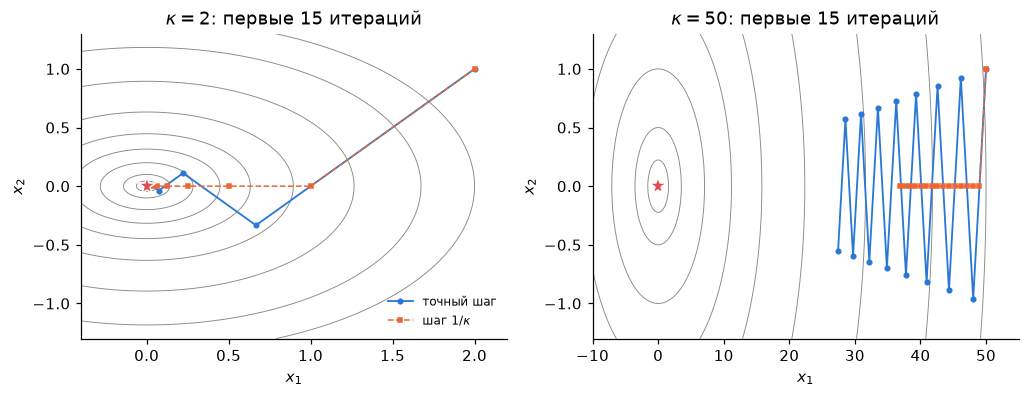

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, kappa in zip(axes, (2, 50)):
    pe, pc = paths_exact[kappa][:16], paths_const[kappa][:16]
    xs = np.linspace(-0.2 * kappa, 1.1 * kappa, 300); ys = np.linspace(-1.3, 1.3, 300)
    X1, X2 = np.meshgrid(xs, ys)
    Fq = 0.5 * (X1**2 + kappa * X2**2)
    ax.contour(X1, X2, Fq, levels=0.5 * kappa**2 * np.array([0.001, 0.005, 0.02, 0.05, 0.1, 0.2, 0.4, 0.7, 1.0]), colors=[GRAY], linewidths=0.6)
    ax.plot(pe[:, 0], pe[:, 1], "-o", ms=3, lw=1.2, color=BLUE, label="точный шаг")
    ax.plot(pc[:, 0], pc[:, 1], "--s", ms=3, lw=1.0, color=ORANGE, label="шаг $1/\\kappa$")
    ax.plot(0, 0, "*", ms=12, color=RED, mec="white")
    ax.set(xlabel="$x_1$", ylabel="$x_2$", title=f"$\\kappa={kappa}$: первые 15 итераций"); ax.grid(False)
axes[0].legend(loc="lower right", fontsize=8)
plt.show()

Итог части (b) словами: **число итераций пропорционально $\kappa$**. Для $\kappa=2$ и $\kappa=50$ отношение итераций (18 : 567 при точном шаге, 28 : 1106 при постоянном) — примерно то же $1:25$, что и $\kappa$. И никакой выбор постоянного шага не спасает: лучший шаг $2/(\kappa+1)$ ускоряет вдвое, но остаётся $\propto\kappa$.

### Демо (d). Логистическая регрессия и масштабирование признаков

Раздел 5 конспекта, упражнение 12.10. Данные из части (0). Метки здесь $y\in\{0,1\}$: $f(w)=\frac1n\sum_i\big[\log(1+e^{x_i^\top w})-y_i\,x_i^\top w\big]$, градиент $\nabla f=\frac1nX^\top(\sigma(Xw)-y)$; для меток $\tilde y_i=2y_i-1\in\{-1,1\}$ из упражнения 12.10 та же формула читается как $\nabla f=-\frac1n\sum_i\sigma(-\tilde y_i\,x_i^\top w)\,\tilde y_i\,x_i$. Гессиан $\nabla^2f=\frac1nX^\top SX$, $S=\operatorname{diag}(\sigma_i(1-\sigma_i))$ — функция выпукла. Гессиан — взвешенная матрица вторых моментов признаков, и здесь его число обусловленности огромное. Причина — **не** «разный масштаб» столбцов (std $10$ у возраста против $1$ у стажа), а **сдвиг**: столбец «возраст $40\pm10$» почти коллинеарен столбцу единиц (косинус угла между ними $\approx0.97$), и $X^\top SX$ почти вырождена. Проверим на трёх вариантах признаков: исходные, только масштабированные (деление на std, средние не трогаем) и стандартизованные (сдвиг + масштаб).

**Исходные признаки.** Минимум находим Ньютоном (должно быть 6 итераций) и считаем $\kappa$ гессиана в нём: ожидаем $\approx7.5\cdot10^4$. Градиентный спуск с backtracking из $w_0=0$, где $\|\nabla f(w_0)\|\approx6.5$, за 20 000 итераций до $\|\nabla f\|\le10^{-6}$ дойти не должен — печатаем, что достиг (ожидаем $\sim5\cdot10^{-3}$: примерно на три порядка вниз из нужных семи).

In [11]:
sigmoid = lambda t: 1 / (1 + np.exp(-t))


def logistic(X, y):
    """Цель, градиент и гессиан логистической регрессии для матрицы признаков X и меток y из {0, 1}."""
    n = len(y)
    f = lambda w: np.mean(np.logaddexp(0, -(2 * y - 1) * (X @ w)))
    grad = lambda w: X.T @ (sigmoid(X @ w) - y) / n

    def hess(w):
        s = sigmoid(X @ w)
        return X.T @ (X * (s * (1 - s))[:, None]) / n

    return f, grad, hess


f_raw, grad_raw, hess_raw = logistic(X, y_cls)
w_raw, k_nraw, _ = newton(grad_raw, hess_raw, np.zeros(3))
lam = np.linalg.eigvalsh(hess_raw(w_raw))
print(f"Ньютон (исходные признаки): {k_nraw} итераций,  w* = {w_raw.round(4)}")
print(f"собственные числа гессиана в оптимуме: {lam},  κ = {lam[-1] / lam[0]:.3g}")
print(f"косинус угла между столбцом единиц и столбцом возраста: {age.mean() / np.sqrt(np.mean(age**2)):.3f}")

g0_norm = np.linalg.norm(grad_raw(np.zeros(3)))
w_graw, k_graw, path_graw = gd(f_raw, grad_raw, np.zeros(3), maxit=20_000)
g_end = np.linalg.norm(grad_raw(w_graw))
print(f"GD backtracking (исходные признаки): |grad f(w0)| = {g0_norm:.2f};  за {k_graw} итераций достигнуто |grad f| = {g_end:.2e} (цель 1e-6),"
      f" то есть уменьшение в {g0_norm / g_end:.0f} раз ≈ {np.log10(g0_norm / g_end):.1f} порядка;  |w_k - w*| = {np.linalg.norm(w_graw - w_raw):.3f}")

Ньютон (исходные признаки): 6 итераций,  w* = [-1.5517  0.1806 -1.0232]
собственные числа гессиана в оптимуме: [2.99396659e-03 1.56712701e-01 2.24729225e+02],  κ = 7.51e+04
косинус угла между столбцом единиц и столбцом возраста: 0.971


GD backtracking (исходные признаки): |grad f(w0)| = 6.48;  за 20000 итераций достигнуто |grad f| = 4.60e-03 (цель 1e-6), то есть уменьшение в 1408 раз ≈ 3.1 порядка;  |w_k - w*| = 0.796


**Только масштаб.** Делим возраст и стаж на их std, средние не трогаем. Если бы дело было в единицах измерения, этого хватило бы. Ожидаем $\kappa$ порядка $10^3$ ($\approx2000$): лучше исходных, но далеко не единицы — деление столбца на константу не меняет угол между ним и столбцом единиц, коллинеарность остаётся. GD с backtracking до $10^{-6}$ здесь доходит, но за несколько тысяч итераций.

In [12]:
sd = X[:, 1:].std(axis=0)
X_sc = np.c_[np.ones(n), X[:, 1:] / sd]
f_sc, grad_sc, hess_sc = logistic(X_sc, y_cls)
w_sc, k_nsc, _ = newton(grad_sc, hess_sc, np.zeros(3))
lam_sc = np.linalg.eigvalsh(hess_sc(w_sc))
print(f"Ньютон (только масштаб): {k_nsc} итераций,  собственные числа гессиана {lam_sc.round(5)},  κ = {lam_sc[-1] / lam_sc[0]:.0f}")
print(f"косинус угла между столбцом единиц и масштабированным возрастом: {X_sc[:, 1].mean() / np.sqrt(np.mean(X_sc[:, 1]**2)):.3f} — тот же")
w_gsc, k_gsc, path_gsc = gd(f_sc, grad_sc, np.zeros(3), maxit=20_000)
print(f"GD backtracking (только масштаб): {k_gsc} итераций, |grad f| = {np.linalg.norm(grad_sc(w_gsc)):.1e}")

Ньютон (только масштаб): 6 итераций,  собственные числа гессиана [2.9600e-03 5.7590e-02 5.9196e+00],  κ = 2000
косинус угла между столбцом единиц и масштабированным возрастом: 0.971 — тот же


GD backtracking (только масштаб): 7495 итераций, |grad f| = 1.0e-06

**Стандартизация: сдвиг + масштаб.** Вычитаем среднее и делим на std каждого признака (столбец единиц не трогаем). Теперь столбцы возраста и стажа ортогональны столбцу единиц. Задача та же — только в других координатах: $w$ пересчитывается обратно аффинно, предсказания совпадают. Ожидаем $\kappa\approx2.75$, GD — 195 итераций, Ньютон — 6.

In [13]:
mu, sd = X[:, 1:].mean(axis=0), X[:, 1:].std(axis=0)
Xs = np.c_[np.ones(n), (X[:, 1:] - mu) / sd]
f_std, grad_std, hess_std = logistic(Xs, y_cls)

w_std, k_nstd, _ = newton(grad_std, hess_std, np.zeros(3))
lam_s = np.linalg.eigvalsh(hess_std(w_std))
print(f"Ньютон (стандартизованные): {k_nstd} итераций,  w* = {w_std.round(4)},  κ = {lam_s[-1] / lam_s[0]:.3f}")
w_gstd, k_gstd, path_gstd = gd(f_std, grad_std, np.zeros(3), maxit=20_000)
print(f"GD backtracking (стандартизованные): {k_gstd} итераций, |grad f| = {np.linalg.norm(grad_std(w_gstd)):.1e}")

# обратно в исходные координаты: w0 + sum_j w_j (x_j - mu_j)/sd_j
w_back = np.r_[w_std[0] - np.sum(w_std[1:] * mu / sd), w_std[1:] / sd]
print(f"w* в исходных координатах: {w_back.round(4)}  (Ньютон на исходных дал {w_raw.round(4)}),  расхождение {np.linalg.norm(w_back - w_raw):.1e}")
acc = np.mean((X @ w_back > 0) == (y_cls == 1))
print(f"точность классификации на обучающих данных: {acc:.3f}")

Ньютон (стандартизованные): 6 итераций,  w* = [ 0.6228  1.8017 -1.0487],  κ = 2.749
GD backtracking (стандартизованные): 195 итераций, |grad f| = 1.0e-06
w* в исходных координатах: [-1.5517  0.1806 -1.0232]  (Ньютон на исходных дал [-1.5517  0.1806 -1.0232]),  расхождение 1.1e-15
точность классификации на обучающих данных: 0.815


**Картинка.** Слева — данные и разделяющая прямая $w^\top x=0$ в исходных координатах. Справа — $\|\nabla f(w_k)\|$ по итерациям для трёх запусков GD: со стандартизацией норма градиента падает с $0.32$ до $10^{-6}$ за 195 итераций; при одном масштабировании — за несколько тысяч; на исходных признаках за 20 000 итераций — примерно на три порядка из семи нужных.

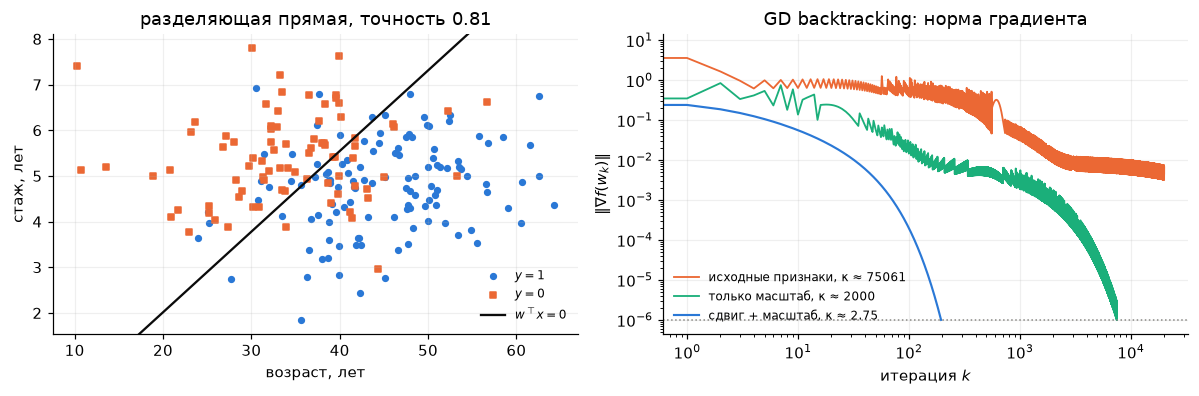

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.7))
ax1.scatter(age[y_cls == 1], exper[y_cls == 1], s=14, color=BLUE, label="$y=1$")
ax1.scatter(age[y_cls == 0], exper[y_cls == 0], s=14, color=ORANGE, marker="s", label="$y=0$")
aa = np.linspace(age.min(), age.max(), 2)
ax1.plot(aa, -(w_back[0] + w_back[1] * aa) / w_back[2], color=INK, lw=1.5, label="$w^\\top x=0$")
ax1.set(xlabel="возраст, лет", ylabel="стаж, лет", ylim=(exper.min() - 0.3, exper.max() + 0.3), title=f"разделяющая прямая, точность {acc:.2f}"); ax1.legend(fontsize=8)

gn_raw = np.linalg.norm(np.array([grad_raw(w) for w in path_graw]), axis=1)
gn_std = np.linalg.norm(np.array([grad_std(w) for w in path_gstd]), axis=1)
gn_sc = np.linalg.norm(np.array([grad_sc(w) for w in path_gsc]), axis=1)
ax2.semilogy(gn_raw, color=ORANGE, lw=1.2, label=f"исходные признаки, κ ≈ {lam[-1] / lam[0]:.0f}")
ax2.semilogy(gn_sc, color=AQUA, lw=1.2, label=f"только масштаб, κ ≈ {lam_sc[-1] / lam_sc[0]:.0f}")
ax2.semilogy(gn_std, color=BLUE, lw=1.4, label=f"сдвиг + масштаб, κ ≈ {lam_s[-1] / lam_s[0]:.2f}")
ax2.axhline(1e-6, color=GRAY, ls=":", lw=1)
ax2.set(xlabel="итерация $k$", ylabel="$\\|\\nabla f(w_k)\\|$", xscale="log", title="GD backtracking: норма градиента"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

Вывод: $\kappa$ здесь определяется не задачей, а **координатами, в которых она записана**, и главный виновник — сдвиг, а не единицы измерения: признак «возраст $40\pm10$» почти коллинеарен столбцу единиц, одно масштабирование этого не лечит ($\kappa\approx2\cdot10^3$), а стандартизация — аффинная замена переменных, сдвиг плюс диагональный масштаб — снижает $\kappa$ с $7.5\cdot10^4$ до $2.75$, не меняя ни ответа, ни точности. Стандартизация признаков — первое лекарство, которое стоит применять до запуска любого градиентного метода (упражнение 12.3д — то же про метры и километры). Ньютон к аффинной замене переменных безразличен: 6 итераций в любом из трёх вариантов.

## 6. Линейная, сверхлинейная, квадратичная

Мы сказали «ошибка сжимается в $q$ раз за шаг». Это — **линейная** сходимость, и не единственно возможная. Пусть $x_k\to x^\ast$.

| Тип | Определение | Что видно на графике $\log\lVert e_k\rVert$ | Верные цифры |
|---|---|---|---|
| линейная | $\lVert e_{k+1}\rVert\le q\lVert e_k\rVert$, $q<1$ | прямая с наклоном $\log q$ | по одной каждые $\ln10/\ln(1/q)$ итераций |
| сверхлинейная | $\lVert e_{k+1}\rVert/\lVert e_k\rVert\to0$ | всё круче и круче | всё больше за шаг |
| квадратичная | $\lVert e_{k+1}\rVert\le C\lVert e_k\rVert^2$ | «обрыв» | число цифр удваивается: $10^{-2},10^{-4},10^{-8},10^{-16}$ |

<img src="img/05_rates.png" width="900" alt="три скорости сходимости и измеренная линейная сходимость градиентного спуска">

Градиентный спуск — линейный с $q=1-1/\kappa$ (с одним и тем же $q$ для всех $k$ начиная с некоторого — иначе линейной сходимостью пришлось бы назвать и $1/k$): на правой картинке ошибка на квадратичной задаче ложится на прямую, и наклон точно $\log_{10}(1-1/\kappa)$. Число обусловленности задаёт наклон, и пока мы шагаем строго против градиента, улучшить его можно только масштабированием. Память о предыдущих шагах — сопряжённые градиенты (лекция 6), момент — снижает цену до $\sim\sqrt\kappa$ итераций, но не меняет типа: это всё ещё прямая. Квадратичная сходимость — это когда из $10^{-2}$ в $10^{-16}$ попадают за три шага; такую даёт метод Ньютона.

## 7. Тизер: один шаг Ньютона

Градиентный спуск использует линейную модель функции. Возьмём квадратичную — Тейлора второго порядка в текущей точке:

$$
m_k(p)=f(x_k)+\nabla f(x_k)^\top p+\tfrac12\,p^\top\nabla^2f(x_k)\,p,
\qquad
\nabla m_k=0\ \Longrightarrow\ \boxed{\;p_k=-\nabla^2f(x_k)^{-1}\nabla f(x_k)\;}
$$

— **шаг Ньютона**. Если $f$ квадратична, модель точна, и шаг попадает в минимум *за одну итерацию* — это ровно $x^\ast=-Q^{-1}c$ из таблицы раздела 3; для цепи это `np.linalg.solve(H, -g)`, одна линейная система вместо $10\,575$ итераций. Если $f$ не квадратична, модель точна лишь вблизи, но там — квадратичная сходимость.

<img src="img/07_newton_teaser.png" width="900" alt="Розенброк: путь градиентного спуска и метода Ньютона, ошибки в логарифмической шкале">

На Розенброке из $(-1.2,1)$: Ньютон — $7$ итераций до $\lVert\nabla f\rVert\le10^{-10}$ (до $10^{-6}$, как у спуска, — $6$), градиентный спуск — $13\,756$. Ошибка Ньютона: $2.2,\ 2.2,\ 4.2,\ 0.48,\ 0.056,\ 10^{-5},\ 10^{-11}$ — сначала два шага почти впустую, на втором даже *хуже* (модель вдали от минимума врёт, и шаг улетает в $(0.77,-3.2)$), зато последние три — удвоение цифр. Числу обусловленности Ньютон безразличен: он делает ту же самую линейную замену координат, что мы делали руками в разделе 5, только автоматически и на каждом шаге — для логистической регрессии он сходится за $6$ итераций что с масштабированием признаков, что без.

Цена: гессиан ($n^2$ чисел) и линейная система ($n^3$ операций), а главное — вдали от минимума шаг может пойти не туда: без линейного поиска Ньютон вообще не метод спуска, $f$ на его шаге может и вырасти (как на второй итерации выше), а если $\nabla^2f$ индефинитен, модель — седло из раздела 3, и её «минимума» не существует. Как это чинится (квази-Ньютон, линейный поиск, доверительная область) — лекции 5 и 6.

### Демо (c). Розенброк: градиентный спуск против Ньютона

Разделы 5–7 конспекта, упражнение 12.4. Старт $(-1.2,1)$. Допуски здесь разные, и это важно там, где сравниваем числа итераций: градиентный спуск останавливаем по $\|\nabla f\|\le10^{-6}$, Ньютона — по $10^{-10}$.

**Backtracking** (Армихо, $c=10^{-4}$: начинаем с $\alpha=1$ и делим пополам) должен дать 13 756 итераций. Чтобы увидеть, какие шаги он реально принимает, заводим локальный вариант `gd_steps` — тот же алгоритм, но возвращает ещё и список принятых $\alpha_k$. Смотрим на самый большой принятый шаг (ожидаем: 30-я итерация, $\alpha=0.5$) и на распределение шагов в хвосте: граница устойчивости у минимума $2/\lambda_{\max}(\nabla^2f(1,1))\approx0.002$, между ней и половиной от неё лежит $2^{-9}\approx0.00195$, а $2^{-8}\approx0.0039$ уже вдвое больше границы.

In [15]:
x0_r = np.array([-1.2, 1.0])
lam_min, lam_max = np.linalg.eigvalsh(rosen_hess(np.array([1.0, 1.0])))


def gd_steps(f, grad, x0, tol=1e-6, maxit=100_000, c=1e-4):
    # тот же backtracking, что в gd, но возвращает ещё и массив принятых шагов alpha_k
    x = np.asarray(x0, float).copy(); path, steps = [x.copy()], []
    for k in range(maxit):
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            break
        a, fx = 1.0, f(x)
        while f(x - a * g) > fx - c * a * (g @ g):
            a /= 2
        steps.append(a); x = x - a * g; path.append(x.copy())
    return x, len(steps), np.array(path), np.array(steps)


x_bt, k_bt, path_bt, steps_bt = gd_steps(rosen, rosen_grad, x0_r)
print(f"backtracking: итераций {k_bt},  x = {x_bt.round(6)},  |grad f| = {np.linalg.norm(rosen_grad(x_bt)):.1e}")
print(f"граница устойчивости в минимуме 2/λ_max = {2 / lam_max:.5f};  2^-9 = {2**-9:.5f},  2^-8 = {2**-8:.5f}\n")

k_jump = int(np.argmax(steps_bt))
print(f"самый большой принятый шаг: итерация {k_jump}, α = {steps_bt[k_jump]};  f: {rosen(path_bt[k_jump]):.2f} -> {rosen(path_bt[k_jump + 1]):.2f};"
      f"  точка после шага {path_bt[k_jump + 1].round(2)}, дно долины под ней: x_2 = x_1^2 = {path_bt[k_jump + 1][0]**2:.2f}")
print("шаги на итерациях 27..33:", ", ".join(f"2^{int(np.log2(a))}" for a in steps_bt[27:34]))
vals, cnt = np.unique(steps_bt, return_counts=True)
print("все принятые шаги:", ",  ".join(f"2^{int(np.log2(v))} — {c_} раз" for v, c_ in zip(vals, cnt)),
      f";  шаг 2^-10 принят на итерациях {np.flatnonzero(steps_bt == 2**-10)}")

tail = np.arange(k_bt - 5000, k_bt)                                  # последние 5000 итераций
vals, cnt = np.unique(steps_bt[tail], return_counts=True)
print("принятые шаги в хвосте:", ",  ".join(f"2^{int(np.log2(v))} — {100 * c_ / len(tail):.1f}%" for v, c_ in zip(vals, cnt)))
gaps = np.diff(np.flatnonzero(steps_bt[tail] == 2**-8))
print(f"шаг 2^-8 принимается каждую {gaps.min()}..{gaps.max()}-ю итерацию")

# доля |grad f|^2 вдоль пологого направления (собственный вектор λ_min) в момент принятия шага
_, V_r = np.linalg.eigh(rosen_hess(np.array([1.0, 1.0])))
flat_share = lambda i: (V_r[:, 0] @ rosen_grad(path_bt[i]))**2 / (rosen_grad(path_bt[i]) @ rosen_grad(path_bt[i]))
sh8 = np.array([flat_share(i) for i in tail if steps_bt[i] == 2**-8]); sh9 = np.array([flat_share(i) for i in tail if steps_bt[i] == 2**-9])
print(f"доля |grad f|^2 вдоль пологого направления: при принятом 2^-8 — {sh8.min():.2f}..{sh8.max():.2f},  при 2^-9 — {sh9.min():.2f}..{sh9.max():.2f}")

backtracking: итераций 13756,  x = [0.999999 0.999998],  |grad f| = 9.8e-07
граница устойчивости в минимуме 2/λ_max = 0.00200;  2^-9 = 0.00195,  2^-8 = 0.00391

самый большой принятый шаг: итерация 30, α = 0.5;  f: 3.94 -> 2.28;  точка после шага [0.87 0.9 ], дно долины под ней: x_2 = x_1^2 = 0.75
шаги на итерациях 27..33: 2^-9, 2^-9, 2^-9, 2^-1, 2^-9, 2^-9, 2^-9
все принятые шаги: 2^-10 — 2 раз,  2^-9 — 12998 раз,  2^-8 — 755 раз,  2^-1 — 1 раз ;  шаг 2^-10 принят на итерациях [0 2]
принятые шаги в хвосте: 2^-9 — 96.1%,  2^-8 — 3.9%
шаг 2^-8 принимается каждую 25..26-ю итерацию
доля |grad f|^2 вдоль пологого направления: при принятом 2^-8 — 0.49..0.51,  при 2^-9 — 0.10..0.49


Что напечаталось. На 30-й итерации принят $\alpha=0.5$: $f$ упала с $3.94$ до $2.28$, и точка перелетела с левой ветви долины на правую, в $(0.87,\,0.90)$ — над дном (дно при $x_1=0.87$ — это $x_2=0.75$). Все остальные шаги — $2^{-9}$ или $2^{-8}$ (плюс дважды $2^{-10}$ на итерациях 0 и 2). В хвосте $96\%$ шагов — $2^{-9}$, и каждый 25–26-й — $2^{-8}$, хотя он вдвое больше границы $2/\lambda_{\max}$ и увеличивает жёсткую компоненту градиента почти втрое ($|1-2^{-8}\lambda_{\max}|\approx2.9$). Армихо его допускает потому, что к этому моменту жёсткая компонента градиента затухла (каждый шаг $2^{-9}$ сжимает её в $|1-2^{-9}\lambda_{\max}|\approx0.96$) и примерно половина $\|\nabla f\|^2$ приходится на пологое направление — для квадратичной модели условие Армихо с $\alpha=2^{-8}$ выполняется ровно при доле $\ge0.49$, что и видно в напечатанном диапазоне. После такого шага жёсткая компонента снова велика, и цикл повторяется.

**Постоянный шаг**, сходящиеся варианты: $\alpha=0.001$ и $0.0019$ (обе меньше $2/\lambda_{\max}\approx0.002$). Ожидаем 32 076 и 16 851 итерацию; у обоих проверяем множитель сжатия на хвосте: $1-\alpha\lambda_{\min}$, как у квадратичной из части (b).

In [16]:
for a in (0.001, 0.0019):
    x, k, path = gd(rosen, rosen_grad, x0_r, alpha=a, maxit=40_000)
    err = np.linalg.norm(path - 1, axis=1)
    print(f"шаг {a:<6}: сошёлся за {k} итераций;  множитель сжатия на хвосте {err[-1] / err[-2]:.5f}, теория 1 - α λ_min = {1 - a * lam_min:.5f}")

шаг 0.001 : сошёлся за 32076 итераций;  множитель сжатия на хвосте 0.99960, теория 1 - α λ_min = 0.99960
шаг 0.0019: сошёлся за 16851 итераций;  множитель сжатия на хвосте 0.99924, теория 1 - α λ_min = 0.99924


**Постоянный шаг за границей**: $\alpha=0.002$ и $0.003$. Метод **не сходится, а колеблется**: точки остаются конечными ($|x|<2$ — долина изогнута и держит), но шаг «перепрыгивает» дно долины, $f$ перестаёт убывать и чередуется между двумя значениями (2-цикл), $\|\nabla f\|$ не падает. Ограничиваем `maxit=40_000`.

In [17]:
for a in (0.002, 0.003):
    with np.errstate(over="ignore", invalid="ignore"):
        x, k, path = gd(rosen, rosen_grad, x0_r, alpha=a, maxit=40_000)
    last_f = ", ".join(f"{rosen(v):.4e}" for v in path[-4:])
    print(f"шаг {a:<6}: {'НЕ сошёлся' if k >= 40_000 else 'сошёлся'} за {k} итераций: |grad f| = {np.linalg.norm(rosen_grad(x)):.2f}, |x| = {np.linalg.norm(x):.2f} (конечна: {np.isfinite(x).all()});  f на последних шагах: {last_f}")

шаг 0.002 : НЕ сошёлся за 40000 итераций: |grad f| = 1.58, |x| = 1.41 (конечна: True);  f на последних шагах: 1.2552e-03, 1.2495e-03, 1.2552e-03, 1.2495e-03
шаг 0.003 : НЕ сошёлся за 40000 итераций: |grad f| = 18.59, |x| = 0.95 (конечна: True);  f на последних шагах: 3.0443e-01, 3.2659e-01, 3.0443e-01, 3.2659e-01


**Ньютон** (раздел 7): $x_{k+1}=x_k-\nabla^2f(x_k)^{-1}\nabla f(x_k)$, без линейного поиска. Должны увидеть 7 итераций до $\|\nabla f\|\le10^{-10}$ и ошибки $2.2,\ 2.21,\ 4.18,\ 0.48,\ 0.056,\ \sim10^{-5},\ \sim10^{-11}$: на первых двух итерациях ошибка не убывает, на второй — **растёт** почти вдвое (точка улетает в $(0.76,-3.18)$) — вдали от минимума чистый Ньютон ненадёжен (лекция 5), зато с четвёртой итерации число верных цифр удваивается на каждом шаге: квадратичная сходимость. Для честного сравнения с GD печатаем и число итераций до общего допуска $10^{-6}$: Ньютону хватает 6.

In [18]:
x_n, k_n, path_n = newton(rosen_grad, rosen_hess, x0_r)
err_n = np.linalg.norm(path_n - 1, axis=1)
print(f"Ньютон: итераций {k_n} до |grad f| <= 1e-10 (до 1e-6, как у GD: {newton(rosen_grad, rosen_hess, x0_r, tol=1e-6)[1]}),  x = {x_n}")
for k, (e, pt) in enumerate(zip(err_n, path_n)):
    print(f"  k = {k}:  x_k = ({pt[0]: .6f}, {pt[1]: .6f})   |e_k| = {e:.2e}" + ("   <- ошибка выросла" if k > 0 and e > err_n[k - 1] else ""))
print("для сравнения из других стартов:", ", ".join(f"{s} -> {newton(rosen_grad, rosen_hess, s)[1]} ит." for s in ((0, 0), (2, 2), (-2, 2))))

Ньютон: итераций 7 до |grad f| <= 1e-10 (до 1e-6, как у GD: 6),  x = [1. 1.]
  k = 0:  x_k = (-1.200000,  1.000000)   |e_k| = 2.20e+00
  k = 1:  x_k = (-1.175281,  1.380674)   |e_k| = 2.21e+00   <- ошибка выросла
  k = 2:  x_k = ( 0.763115, -3.175034)   |e_k| = 4.18e+00   <- ошибка выросла
  k = 3:  x_k = ( 0.763430,  0.582825)   |e_k| = 4.80e-01
  k = 4:  x_k = ( 0.999995,  0.944027)   |e_k| = 5.60e-02
  k = 5:  x_k = ( 0.999996,  0.999991)   |e_k| = 9.62e-06
  k = 6:  x_k = ( 1.000000,  1.000000)   |e_k| = 1.85e-11
  k = 7:  x_k = ( 1.000000,  1.000000)   |e_k| = 0.00e+00
для сравнения из других стартов: (0, 0) -> 2 ит., (2, 2) -> 5 ит., (-2, 2) -> 6 ит.


**Две картинки.** Слева — пути на линиях уровня: GD (первые 40 точек целиком, дальше каждая 200-я) за пару итераций падает на дно левой ветви долины, а на 30-й backtracking принимает большой шаг $\alpha=0.5$ (условие Армихо выполнено: $f$ упала с $3.94$ до $2.28$) и точка перелетает через горб на правую ветвь, в $(0.87,0.90)$ над дном долины — и дальше 13 700 мелких шагов $2^{-9}$ (изредка $2^{-8}$) ползёт по дну к $(1,1)$; Ньютон делает 7 больших шагов, второй из них уводит в $(0.76,-3.18)$ — за нижний край картинки (ось $x_2$ обрезана, чтобы эта точка не растягивала масштаб; она подписана). Справа — $\log_{10}\|e_k\|$: у GD прямая (линейная сходимость, ошибка умножается на постоянный множитель), у Ньютона — обрыв (квадратичная: наклон растёт с каждым шагом). Оси $k$ разные: GD показан на первых 2000 итерациях, Ньютон — на всех 7.

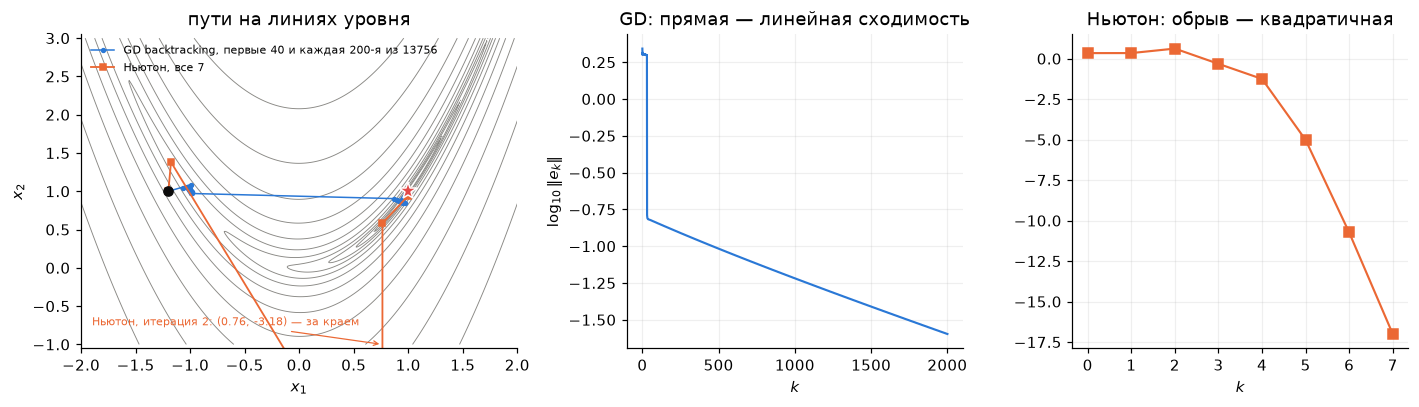

In [19]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1.3, 1, 1]})
ax1.contour(X1_r := np.linspace(-2, 2, 400)[None, :] * np.ones((400, 1)), X2_r := np.linspace(-1, 3, 400)[:, None] * np.ones((1, 400)),
            (1 - X1_r)**2 + 100 * (X2_r - X1_r**2)**2, levels=np.logspace(-1, 3, 12), colors=[GRAY], linewidths=0.6)
gd_pts = np.r_[path_bt[:40], path_bt[40::200]]        # первые 40 точек целиком (спуск на дно), дальше каждая 200-я
ax1.plot(gd_pts[:, 0], gd_pts[:, 1], "-o", ms=2.5, lw=1, color=BLUE, label=f"GD backtracking, первые 40 и каждая 200-я из {k_bt}")
ax1.plot(path_n[:, 0], path_n[:, 1], "-s", ms=4, lw=1.2, color=ORANGE, label=f"Ньютон, все {k_n}")
ax1.plot(1, 1, "*", ms=12, color=RED, mec="white"); ax1.plot(-1.2, 1, "o", color=INK)
ax1.set(xlabel="$x_1$", ylabel="$x_2$", ylim=(-1.05, 3.05), title="пути на линиях уровня"); ax1.legend(loc="upper left", fontsize=7.5); ax1.grid(False)
ax1.annotate(f"Ньютон, итерация 2: ({path_n[2, 0]:.2f}, {path_n[2, 1]:.2f}) — за краем", xy=(path_n[2, 0], -1.0), xytext=(-1.9, -0.75),
             fontsize=7.5, color=ORANGE, arrowprops=dict(arrowstyle="->", color=ORANGE, lw=0.8))

err_bt = np.linalg.norm(path_bt - 1, axis=1)
ax2.plot(np.arange(2001), np.log10(err_bt[:2001]), color=BLUE, lw=1.4)
ax2.set(xlabel="$k$", ylabel="$\\log_{10}\\|e_k\\|$", title="GD: прямая — линейная сходимость")
ax3.plot(np.arange(len(err_n)), np.log10(err_n + 1e-17), "-s", color=ORANGE, lw=1.4)
ax3.set(xlabel="$k$", title="Ньютон: обрыв — квадратичная", xticks=range(len(err_n)))
plt.tight_layout(); plt.show()

Сравните с оценкой из упражнения 12.4: множитель $1-1/\kappa$ при $\kappa=2508$ означает $\approx\kappa\ln10^6\approx3.5\cdot10^4$ итераций на уменьшение ошибки в $10^6$ раз — того же порядка, что 32 076 у шага $0.001$. Backtracking быстрее шага $0.001$ (13 756 против 32 076) не потому, что «долина широкая», а из-за величины шага у дна: его $2^{-9}\approx0.00195$ (и каждый 25-й — $2^{-8}$) вдвое ближе к границе $2/\lambda_{\max}\approx0.002$, ровно как постоянный шаг $0.0019$ с его 16 851 итерацией. Все три остаются линейными, а за границей метод не сходится вовсе. Ньютону $\kappa$ безразлично: 7 итераций до $10^{-10}$, 6 — до общего с GD допуска $10^{-6}$.

### Демо (e). Цепь: $\kappa$ растёт с числом грузов

Раздел 5 конспекта, упражнение 12.9. Гессиан энергии — $\operatorname{diag}(DK,DK)$, поэтому $\kappa(\nabla^2E)=\kappa(K)$, а собственные числа $K$ известны: $2-2\cos\frac{j\pi}{N+1}$, откуда $\kappa\approx\big(\tfrac{2(N+1)}{\pi}\big)^2$. Проверяем таблицей для $N=10,20,40,80$: должны увидеть $48.4,\ 178.1,\ 680.6,\ 2658.4$ против формулы $49.0,\ 178.7,\ 681.3,\ 2659.1$ — $\kappa$ растёт как $N^2$. Чем мельче дробим цепь, тем хуже обусловлена задача.

In [20]:
print(" N   κ(K)      (2(N+1)/π)^2    λ_max(H)=L")
for N_ in (10, 20, 40, 80):
    _, _, _, K_, H_, _ = make_chain(N_)
    lamK = np.linalg.eigvalsh(K_)
    print(f"{N_:3d}  {lamK[-1] / lamK[0]:8.1f}   {(2 * (N_ + 1) / np.pi)**2:8.1f}        {D_CHAIN * lamK[-1]:.1f}")

 N   κ(K)      (2(N+1)/π)^2    λ_max(H)=L
 10      48.4       49.0        274.3
 20     178.1      178.7        278.4
 40     680.6      681.3        279.6
 80    2658.4     2659.1        279.9


**$N=40$: спуск против одного шага Ньютона.** Константа Липшица градиента $L=\lambda_{\max}(\nabla^2E)\approx279.6$, берём шаг $1/L$ и стартуем с прямой между концами. Ожидаем 10 575 итераций до $\|\nabla E\|\le10^{-6}$ и энергию $13.4417$. Оценка из раздела 5: множитель $1-1/\kappa$ при $\kappa\approx680.6$; в старте $\|\nabla E(v_0)\|\approx6.2$, до порога её надо уменьшить в $6.2\cdot10^6$ раз, то есть $\approx\kappa\ln(6.2\cdot10^6)\approx10\,645$ итераций — против факта 10 575. Функция квадратичная, поэтому квадратичная модель Ньютона точна и один шаг $-H^{-1}\nabla E$ из любой точки попадает в минимум — это ровно `np.linalg.solve(H, -grad(0))` из части (0); расхождение двух ответов должно быть на уровне допуска $10^{-6}$.

In [21]:
energy, grad_E, unpack, K, H, v0 = make_chain(40)
lam_H = np.linalg.eigvalsh(H); L, kappa40 = lam_H[-1], lam_H[-1] / lam_H[0]
print(f"L = λ_max(H) = {L:.1f},  шаг 1/L = {1 / L:.5f},  κ = {kappa40:.1f}")
v_gd, k_gd, path_gd = gd(energy, grad_E, v0, alpha=1 / L)
print(f"GD с шагом 1/L: итераций {k_gd},  энергия {energy(v_gd):.4f},  |grad E| = {np.linalg.norm(grad_E(v_gd)):.1e}")
g0 = np.linalg.norm(grad_E(v0))
print(f"оценка: |grad E(v0)| = {g0:.2f}, уменьшить в {g0 / 1e-6:.2g} раз;  κ·ln(|grad E(v0)|/1e-6) = {kappa40 * np.log(g0 / 1e-6):.0f} итераций против факта {k_gd}")
v_newton = v0 - np.linalg.solve(H, grad_E(v0))          # один шаг Ньютона из старта
print(f"один шаг Ньютона:  энергия {energy(v_newton):.4f},  |grad E| = {np.linalg.norm(grad_E(v_newton)):.1e}")
print(f"расхождение GD и Ньютона: max |Δv| = {np.abs(v_gd - v_newton).max():.1e},  |Δv| = {np.linalg.norm(v_gd - v_newton):.1e};  с решением из части (0): {np.linalg.norm(v_newton - v_chain):.1e}")

L = λ_max(H) = 279.6,  шаг 1/L = 0.00358,  κ = 680.6


GD с шагом 1/L: итераций 10575,  энергия 13.4417,  |grad E| = 1.0e-06
оценка: |grad E(v0)| = 6.20, уменьшить в 6.2e+06 раз;  κ·ln(|grad E(v0)|/1e-6) = 10645 итераций против факта 10575
один шаг Ньютона:  энергия 13.4417,  |grad E| = 1.5e-13
расхождение GD и Ньютона: max |Δv| = 5.4e-07,  |Δv| = 2.4e-06;  с решением из части (0): 3.0e-14


**Число итераций от $N$.** Тот же спуск с шагом $1/L$ для $N=10,20,40,80$ (`maxit=60_000`; для $N=40$ результат берём из предыдущей ячейки). Ожидаем рост $\propto\kappa\propto N^2$: удвоение числа грузов — вчетверо больше итераций. В таблице — столбец $k_N/\kappa_N$: он должен держаться около $15$–$16$ при всех $N$ (это $\approx\ln(\|\nabla E(v_0)\|/10^{-6})$; чуть убывает, потому что $\|\nabla E(v_0)\|$ с ростом $N$ убывает) — то самое «итераций $\propto\kappa$». Пунктир на графике — $k_{40}\cdot\kappa(N)/\kappa(40)$.

N = 10: κ =    48.4,  итераций GD:    779,  k/κ = 16.1,  |grad E(v0)| = 12.4
N = 20: κ =   178.1,  итераций GD:   2825,  k/κ = 15.9,  |grad E(v0)| = 8.8
N = 40: κ =   680.6,  итераций GD:  10575,  k/κ = 15.5,  |grad E(v0)| = 6.2


N = 80: κ =  2658.4,  итераций GD:  40388,  k/κ = 15.2,  |grad E(v0)| = 4.4


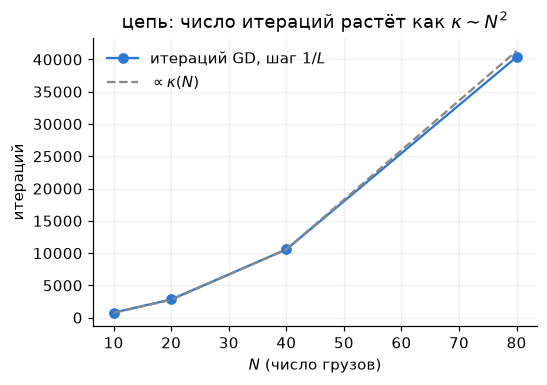

In [22]:
Ns, iters, kappas = (10, 20, 40, 80), [], []
for N_ in Ns:
    e_, g_, _, K_, H_, v0_ = make_chain(N_)
    lamK = np.linalg.eigvalsh(K_); kappas.append(lamK[-1] / lamK[0])
    if N_ == 40:
        k_ = k_gd                                                   # уже посчитано в предыдущей ячейке
    else:
        _, k_, _ = gd(e_, g_, v0_, alpha=1 / (D_CHAIN * lamK[-1]), maxit=60_000)
    iters.append(k_)
    print(f"N = {N_:2d}: κ = {kappas[-1]:7.1f},  итераций GD: {k_:6d},  k/κ = {k_ / kappas[-1]:.1f},  |grad E(v0)| = {np.linalg.norm(g_(v0_)):.1f}"
          + ("  (упёрлись в maxit)" if k_ >= 60_000 else ""))
kappas, iters = np.array(kappas), np.array(iters)

plt.figure(figsize=(5.2, 3.4))
plt.plot(Ns, iters, "o-", color=BLUE, label="итераций GD, шаг $1/L$")
plt.plot(Ns, iters[2] * kappas / kappas[2], "--", color=GRAY, label="$\\propto\\kappa(N)$")
plt.xlabel("$N$ (число грузов)"); plt.ylabel("итераций"); plt.legend(); plt.title("цепь: число итераций растёт как $\\kappa\\sim N^2$")
plt.show()

Один и тот же метод, одна и та же физика — и в четыре раза больше итераций на каждое удвоение $N$: число обусловленности растёт с размерностью, а вместе с ним и цена градиентного спуска. Ньютон (здесь — одна линейная система) от $N$ так не зависит. Что делать, когда гессиан считать дорого или он не положительно определён, — лекция 5.

## 8. Что это даёт численно

**Диагноз по графику.** Постройте $\log\lVert\nabla f(x_k)\rVert$ или $\log(f(x_k)-f^\ast)$ по итерациям. Прямая с пологим наклоном — линейная сходимость с большим $\kappa$: проверьте масштабы переменных, прежде чем менять метод. Обрыв — ньютоновская сходимость: вы в области, где квадратичная модель точна.

**Стационарная точка — ещё не минимум.** Для невыпуклой $f$ малый градиент не различает минимум и седло. Если есть сомнения — собственные числа гессиана в найденной точке (демо, часть a); отрицательное собственное число указывает направление, вдоль которого можно спуститься ещё.

**Что делает `minimize` по умолчанию.** Без ограничений SciPy запускает BFGS — квази-ньютоновский метод: он не считает гессиан, а восстанавливает его по градиентам, и сходится сверхлинейно. Это тема лекции 5; после неё вы напишете градиентный спуск, Ньютон и BFGS сами и сравните их на Розенброке, цепи и регрессии (ДЗ 3).

**Откуда брать градиент.** В демо все градиенты выписаны руками. Что делать, когда $f$ — тысяча строк кода, — лекция 7: конечные разности и их погрешность, алгоритмическое дифференцирование.

## 9. Итоги лекции

1. Минимум — стационарная точка: $\nabla f(x^\ast)=0$. Обратное неверно: стационарной бывает и седло, и максимум.
2. Второй порядок: $\nabla^2f\succeq0$ необходимо, $\nabla^2f\succ0$ достаточно; между ними — зазор ($x^4$, $x^3$, $-x^4$), который закрывает только выпуклость. Для квадратичных функций ответ полный: чаша, седло, жёлоб.
3. Градиентный спуск $x_{k+1}=x_k-\alpha\nabla f(x_k)$: антиградиент — самый крутой спуск ($g^\top p=\lVert g\rVert\cos\theta$). Кривизна не больше $L$ ⇒ функция под параболой ⇒ шаг $\alpha<2/L$ гарантирует убывание, $1/L$ — лучший гарантированный; точный шаг на квадратичной — $\lVert g\rVert^2/g^\top Qg$; backtracking — рабочий рецепт без знания $L$.
4. Скорость линейная с множителем $1-1/\kappa$ для ошибки: итераций $\approx\kappa\ln(1/\varepsilon)$. **Число обусловленности** $\kappa=\lambda_{\max}/\lambda_{\min}$ — то, что вблизи минимума определяет, ползёт метод или летит.
5. $\kappa$ — свойство координат, а не задачи: масштабирование переменных (предобуславливание) — первое лекарство. Розенброк $\kappa\approx2500$, цепь $\kappa\sim N^2$, регрессия без стандартизации $\kappa\sim10^5$.
6. Линейная, сверхлинейная, квадратичная сходимость — «сколько цифр прибавляет шаг». Ньютон: квадратичная модель, один шаг на квадратичной задаче, $7$ итераций против $13\,756$ на Розенброке — но только вблизи минимума и за цену гессиана.

## 10. Что дальше

**Лекция 5** — метод Ньютона всерьёз: локальная сходимость и теорема о сжатии, квази-ньютоновские обновления (BFGS, L-BFGS), метод Гаусса–Ньютона для задач МНК, и почему для всех них важно то, что мы сегодня увидели на Розенброке. **Лекция 6** — что делать вдали от минимума: линейный поиск (Армихо, Вольфе), доверительная область, сопряжённые градиенты. **Лекция 7** — как считать производные.

**Домашнее задание 3** выдаётся 7 октября, после лекции 5: градиентный спуск, Ньютон и BFGS — реализация и сравнение на сегодняшних задачах (см. [программу курса](../../syllabus.md#4-домашние-задания)). **Домашнее задание 2** — срок 7 октября.

**Литература к лекции.** Diehl, гл. 4 (условия оптимальности без ограничений) и §5.1 (скорости сходимости); Nocedal & Wright, §2.1 (условия оптимальности), §2.2 и §3.3 (направления спуска, скорость градиентного метода); Boyd & Vandenberghe, §9.1–9.3 (сильная выпуклость, число обусловленности, градиентный метод); Поляк, гл. 1 (градиентный метод).

## 11. Семинар: задачи у доски

Вторая половина пары, ~33 минуты, — задачи, которые решаются руками. Код демонстраций встроен в конспект-ноутбук [`lecture04.ipynb`](lecture04.ipynb) («Демо (0)»–«Демо (e)»); на лекции его запускаем по ходу, а на семинаре к нему возвращаемся точечно: Демо (b) — к 12.3, Демо (c) — к 12.4. Дома то же самое целиком — [`demo04.ipynb`](demo04.ipynb). Условия — в разделе 12, разбор с ответами — в [`exercises04.ipynb`](exercises04.ipynb).

| Мин | Задача | Что тренирует |
|-----|--------|---------------|
| 5 | **12.1** Стационарные точки $(x_1^2-1)^2+x_2^2$: седло и два минимума по гессиану; куда придёт спуск из $(0,0.5)$ | классификация по гессиану; седло — ловушка для спуска |
| 12 | **12.3** Спуск на $\tfrac12(x_1^2+\kappa x_2^2)$ с постоянным шагом: диапазон $\alpha$, лучший $\alpha$ по картинке двух множителей, итераций на одну цифру; (д) километры против метров — $\kappa=10^6$ из ничего | откуда берётся $\kappa$ — руками, покоординатно; масштабирование = замена переменных |
| 6 | **12.4** Розенброк: гессиан в $(1,1)$, $\kappa$ через след и определитель, оценка числа итераций против демо | оценка $\kappa\ln(1/\varepsilon)$ на живых числах |
| 4 | **12.7** Четыре последовательности ошибок — назвать тип сходимости хором | линейная / сверхлинейная / квадратичная на слух |
| 6 | **12.5** Прочитать график сходимости: по наклону восстановить $\kappa$, число итераций, решить, масштабировать ли | диагноз по графику — то, что придётся делать в ДЗ 3 |

Дома: 12.2 (зазор второго порядка, пример Пеано), 12.6 (лемма о спуске — доказать), 12.8 (самый крутой спуск и ортогональность), 12.9 (цепь: $\kappa\sim N^2$), 12.10 (логистическая регрессия: гессиан и почему помогает стандартизация); затем прогнать демонстрации (a)–(e) — в конспекте-ноутбуке или отдельно в `demo04.ipynb`.

## 12. Упражнения

Для разбора на занятии и самостоятельно. Подробный разбор с проверкой кодом — ноутбук [`exercises04.ipynb`](exercises04.ipynb), краткие ответы — [`exercises04.md`](exercises04.md).

**12.1.** Стационарные точки $f(x)=(x_1^2-1)^2+x_2^2$ (пример лекции 2, §4). Найдите все точки с $\nabla f=0$, выпишите гессиан в каждой и классифицируйте: минимум, максимум, седло. Сверьте с картой $\lambda_{\min}\nabla^2f$ из лекции 2. Куда придёт градиентный спуск из $(0,\,0.5)$? Из $(0.01,\,0.5)$?

**12.2.** Зазор между необходимым и достаточным условием. (а) Для $x^4$, $x^3$, $-x^4$ в нуле: что говорят условия первого и второго порядка и что на самом деле? (б) То же для $f(x)=x_1^2+x_2^4$ и $g(x)=x_1^2-x_2^4$ в нуле: гессианы одинаковы, а судьбы разные. (в) Пример Пеано: $f(x)=(x_2-x_1^2)(x_2-2x_1^2)$. Покажите, что $\nabla f(0)=0$ и $\nabla^2f(0)=\operatorname{diag}(0,2)\succeq0$; что вдоль любой прямой через нуль функция имеет в нуле строгий локальный минимум; и что нуль всё же не локальный минимум — найдите точки сколь угодно близко к нулю с $f<0$. Что это говорит о проверке «по направлениям»?

**12.3.** Градиентный спуск на $f(x)=\tfrac12(x_1^2+\kappa x_2^2)$, $\kappa\ge1$, с постоянным шагом $\alpha$. (а) Выпишите итерацию покоординатно. (б) При каких $\alpha$ метод сходится из любой точки? (в) Какой $\alpha$ даёт наименьший множитель сжатия $\max(|1-\alpha|,\,|1-\alpha\kappa|)$ и чему он равен? Нарисуйте оба множителя как функции $\alpha$. (г) Сколько итераций нужно на одну верную десятичную цифру при $\kappa=50$ для $\alpha=1/\kappa$ и для лучшего $\alpha$? Почему при обоих шагах $f$ сжимается за итерацию в квадрат множителя для ошибки? (д) Единицы измерения: пусть $f=\tfrac12(x_1^2+x_2^2)$, обе координаты — метры, $\kappa=1$. Перепишите $f$ через $u_1=x_1/1000$ (километры), $u_2=x_2$: чему равно $\kappa$ и сколько итераций на одну цифру? Покажите, что шаг $u\leftarrow u-\alpha D^{-1}\nabla_uf(u)$ с $D=\operatorname{diag}(10^6,1)$ — это спуск в исходных переменных, а при $D=\nabla^2f$ и $\alpha=1$ — шаг Ньютона (раздел 7).

**12.4.** Розенброк $f(x)=(1-x_1)^2+100(x_2-x_1^2)^2$. Выпишите гессиан в $(1,1)$, найдите его собственные числа и $\kappa$. Оцените, сколько итераций градиентного спуска с шагом $1/\lambda_{\max}$ нужно, чтобы вблизи минимума уменьшить ошибку в $10^6$ раз. Сравните с числом итераций из демо (часть c) и с методом Ньютона.

**12.5.** Прочитайте график. Градиентный спуск с постоянным шагом $1/L$ на сильно выпуклой функции стартовал с $\|\nabla f(x_0)\|=1$ и остановился по $\|\nabla f\|\le10^{-8}$; $\log_{10}\|\nabla f(x_k)\|$ лёг на прямую с наклоном $-0.0004$ на итерацию. (а) Каков множитель сжатия $q$ за итерацию и какому $\kappa$ он соответствует? (б) Сколько итераций понадобилось? (в) Стоит ли масштабировать переменные перед повторным запуском и как изменится график? (г) Как выглядел бы график, если бы метод сменили на ньютоновский?

**12.6.** Лемма о спуске. Пусть $\|\nabla f(x)-\nabla f(y)\|\le L\|x-y\|$ для всех $x,y$. Докажите, что $f(y)\le f(x)+\nabla f(x)^\top(y-x)+\tfrac L2\|y-x\|^2$ (подсказка: $f(y)-f(x)=\int_0^1\nabla f(x+t(y-x))^\top(y-x)\,dt$), и выведите $f(x-\alpha\nabla f(x))\le f(x)-\alpha\big(1-\tfrac{\alpha L}2\big)\|\nabla f(x)\|^2$. При каких $\alpha$ функция гарантированно убывает? Какой $\alpha$ даёт наибольшее гарантированное убывание? Чему равно $L$ для квадратичной $\tfrac12x^\top Qx$, $Q\succeq0$?

**12.7.** Скорость по последовательности. Даны ошибки $\|e_k\|$ четырёх методов: (а) $10^{-1},10^{-2},10^{-3},10^{-4},\dots$; (б) $10^{-1},10^{-2},10^{-4},10^{-8},\dots$; (в) $1/k$; (г) $1/k!$. Определите тип сходимости каждой (линейная — с каким множителем, сверхлинейная, квадратичная, ни одна из них). Сколько итераций нужно каждой, чтобы от ошибки $\le10^{-1}$ дойти до $\le10^{-12}$?

**12.8.** Направление наискорейшего спуска. (а) Докажите, что среди единичных векторов $p$ производная по направлению $\nabla f(x)^\top p$ минимальна при $p=-\nabla f(x)/\|\nabla f(x)\|$. (б) Докажите, что $\nabla f(x)$ ортогонален линии уровня $\{y: f(y)=f(x)\}$ (подсказка: продифференцируйте $f(\gamma(t))=\mathrm{const}$ вдоль кривой $\gamma$ на линии уровня). (в) Покажите, что при точном линейном поиске $\nabla f(x_{k+1})\perp\nabla f(x_k)$ — отсюда зигзаг на картинке 04.

**12.9.** Цепь без пола (лекция 1, §7.3). Покажите, что гессиан энергии — блочно-диагональная матрица $\operatorname{diag}(DK,\,DK)$ с трёхдиагональной $K$ ($2$ на диагонали, $-1$ рядом), не зависящая от $x$. Собственные числа $K$ равны $2-2\cos\frac{j\pi}{N+1}$, $j=1,\dots,N$ (примите без доказательства). Найдите $\kappa$ как функцию $N$ и покажите, что $\kappa\approx\big(\tfrac{2(N+1)}{\pi}\big)^2$ при больших $N$. Оцените, сколько итераций градиентного спуска нужно при $N=40$, чтобы уменьшить ошибку в $10^6$ раз, и сколько шагов Ньютона. Почему здесь Ньютон — это просто `np.linalg.solve`?

**12.10.** Логистическая регрессия (лекция 1, §7.5; данные — демо лекции 2, часть d). Для $f(w)=\frac1n\sum_{i=1}^n\log\big(1+e^{-y_i\,x_i^\top w}\big)$, $y_i\in\{-1,1\}$, найдите $\nabla f$ и $\nabla^2f$ и покажите, что $\nabla^2f=\frac1nX^\top SX$ с диагональной $S\succeq0$. Гессиан — взвешенная матрица вторых моментов признаков: объясните, почему признак «возраст $40\pm10$» вместе со столбцом единиц даёт большое $\kappa$ (подсказка: столбцы почти коллинеарны), почему одно масштабирование признаков этого не лечит, а стандартизация — сдвиг плюс масштаб — лечит.

**Домашнее задание 3** — по градиентным методам, выдаётся 7 октября.

## Вопросы для самопроверки

1. Почему в локальном минимуме $\nabla f=0$, и почему из $\nabla f=0$ минимум не следует? Приведите по примеру седла и максимума.
2. В чём зазор между $\nabla^2f\succeq0$ и $\nabla^2f\succ0$? Какие три функции одной переменной его демонстрируют, и что происходит с зазором для выпуклых функций?
3. Почему антиградиент — самый крутой спуск? Что такое направление спуска вообще, и как выглядит их множество на картинке линий уровня?
4. Что гарантирует лемма о спуске и при каких шагах? Что произойдёт при $\alpha>2/L$ — на квадратичной функции и на Розенброке?
5. Что такое число обусловленности, как оно входит в число итераций градиентного спуска и почему масштабирование переменных его меняет, хотя задача та же?
6. Как по графику $\log\lVert e_k\rVert$ отличить линейную, сверхлинейную и квадратичную сходимость? Какая у градиентного спуска и какая у Ньютона?